# Data
### Both datasets consist of 2d rgb images representing visualized malicious activity

## 48240 dataset (malicious binaries/files etc)
https://ieee-dataport.org/documents/48240-malware-samples-and-binary-visualisation-images-machine-learning-anomaly-detection

## 913 dataset (malicious network traffic) 
https://ieee-dataport.org/open-access/913-malicious-network-traffic-pcaps-and-binary-visualisation-images-dataset

# Prerequisites
## Preferred Tensorflow version

In [ ]:
import tensorflow as tf
print(tf.__version__)
!pip install tensorflow-gpu==2.10.0
#!pip install tensorflow[and-cuda]==2.12.0
# restart kernel after installation finishes, then its ready to train on the new version of tensorflow
# the tensorflow version 2.10 was the last to support gpu natively on windows, then starting from 2.11 and up on windows wsl is required for gpu allocation

# 0. Standard training
### The standard training procedure, training is done on the dataset's initial state, without applying any transforms and modifications to them

## 0.1. "Stock" dataset training on 48240 dataset

In [ ]:
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
#from tensorflow import keras
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization,MaxPool2D
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam
from keras.regularizers import *
from keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from keras.initializers import he_normal  
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import time
print(tf.__version__)
#print(keras.__version__)
from PIL import ImageFont
import matplotlib.pyplot as plt
import random as rn
import os

start_time = time.time()
results = {}

#-------------
# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
setup_seed(42)
#------------

img_width, img_height = 32, 32
batch_size = 64  
epochs = 1
learn_rate = 0.01

#"""
# -- Creating custom model --
if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

model = Sequential()

# Reduce the size of the convolutional layers
model.add(Conv2D(8, (1, 1), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
#model.add(Dropout(0.1))

model.add(Conv2D(16, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2)) 
#model.add(Dropout(0.1))

model.add(Conv2D(32, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
#model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
#"""

"""
from tensorflow.keras.applications import MobileNetV3Small
#base_model = MobileNetV3Small(include_top=False, input_shape=(img_width,img_height, 3))
base_model = MobileNetV3Small(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
# Freeze all layers in the base model
for layer in base_model.layers:
    layer.trainable = False
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
# Ensure the classification layer is trainable
model.layers[-1].trainable = True
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
"""

"""
from tensorflow.keras.applications import MobileNetV3Large
base_model = MobileNetV3Large(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False
# Ensure the classification layer is trainable
model.layers[-1].trainable = True
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
"""

model.compile(optimizer=Adam(learning_rate=learn_rate), loss='binary_crossentropy', metrics=['accuracy'])
train_dataset = '/kaggle/input/data-48240-60-15-25/Data_48240_60_15_25/Training'
valid_dataset = '/kaggle/input/data-48240-60-15-25/Data_48240_60_15_25/Validation'
testing_path = '/kaggle/input/data-48240-60-15-25/Data_48240_60_15_25/Test'

train_generator = datagen.flow_from_directory(
   train_dataset,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True)
valid_generator = datagen.flow_from_directory(
    valid_dataset,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False)

#test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = datagen.flow_from_directory(
    testing_path, 
    target_size=(img_width, img_height), 
    batch_size=batch_size, 
    class_mode='binary', 
    shuffle=False)

lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',    # Monitor validation loss
    factor=0.3,            # Factor by which the learning rate will be reduced (new_lr = lr * factor)
    patience=3,            # Number of epochs with no improvement after which learning rate will be reduced
    verbose=1,             # Provide output about learning rate changes
    min_lr=1e-8            # Minimum learning rate (optional) (1e-6 = 0.000001)
)

Early_Stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights='True',
    #min_delta=0.1
)

# Checkpoints, save best only true saves the ENTIRE MODEL + its weights, meaning if i wanna retrain i just load model
checkpoint = ModelCheckpoint("best_model.hdf5", monitor='val_loss', verbose=1, save_best_only=True, mode='min', period=1)
callbacks_list = [checkpoint,lr_schedule,Early_Stopping]

# -- Training --
history = model.fit(train_generator, steps_per_epoch=train_generator.n // batch_size, epochs=epochs, validation_data=valid_generator, validation_steps=valid_generator.n // batch_size, callbacks=callbacks_list)
# Loading best model
model.load_weights('best_model.hdf5')
# Evaluating model
valid_generator.reset()
Y_pred = model.predict(valid_generator, valid_generator.n // batch_size + 1)
y_pred = np.where(Y_pred > 0.5, 1, 0)
#model.summary()
print(f"\n-----\n{train_dataset}\n{valid_dataset}\n-----")
#target_names = ['Malware', 'Software']
#print(f"imgWidth = {img_width}, imgHeight = {img_height}\nepochs = {epochs}\nbatch size = {batch_size}\nlearning rate = {learn_rate}\n-----")
print('Confusion Matrix')
cm = confusion_matrix(valid_generator.classes, y_pred)
print(cm)
#print('Classification Report')
#print(classification_report(valid_generator.classes, y_pred, target_names=target_names,zero_division=1,digits=5))
TN, FP, FN, TP = cm.ravel()
print(f"True Positives  (actual Software) (TP): {TP}")
print(f"False Negatives (missed Software) (FN): {FN}")
print(f"True Negatives  (actual Malware)  (TN): {TN}")
print(f"False Positives (missed Malware)  (FP): {FP}")

target_names = ['Malware', 'Software']
print(f"\nimgWidth = {img_width}, imgHeight = {img_height}\nepochs = {epochs}\nbatch size = {batch_size}\nlearning rate = {learn_rate}")
#model.summary()
print('\nClassification Report')
print(classification_report(valid_generator.classes, y_pred, target_names=target_names,zero_division=1,digits=5))

tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True, 
                          show_dtype=False,show_layer_names=True, 
                          rankdir='TB', expand_nested=False, dpi=96)
#model.summary()
#import visualkeras
#visualkeras.layered_view(model, legend=True) 

# Plot training and validation loss and learning rate side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Plot Training and Validation Loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot Learning Rate
axes[1].plot(history.history['lr'], label='Learning Rate', color='red')
axes[1].set_title('Learning Rate')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Learning Rate')
axes[1].legend()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

#testing
model.load_weights('best_model.hdf5')
# Predict classes
Y_pred_test = model.predict(test_generator, test_generator.samples // test_generator.batch_size+1)
test_labels = (Y_pred_test > 0.5).astype(int)
print(test_generator.class_indices)
cm = confusion_matrix(test_generator.classes, test_labels)
TN, FP, FN, TP = cm.ravel()
print("[[TN FP]\n[FN TP]]")
print(f"True Positives  (actual Software) (TP): {TP}")
print(f"False Negatives (missed Software) (FN): {FN}")
print(f"True Negatives  (actual Malware)  (TN): {TN}")
print(f"False Positives (missed Malware)  (FP): {FP}")
# Calculate precision, recall, and f1-score for Malware class
print("\nClassification report")
print(classification_report(test_generator.classes, test_labels, zero_division=1, target_names=target_names, digits=5))
report = classification_report(test_generator.classes, test_labels, digits=5, zero_division=1, output_dict=True)

# Extract overall metrics, for a binary classification with 'class_0' and 'class_1', class_0 = malware, class_1 = software
accuracy = report['accuracy']

# Extract metrics for each class
precision_class_0 = report['0']['precision']
recall_class_0 = report['0']['recall']
f1_score_class_0 = report['0']['f1-score']
support_class_0 = report['0']['support']
precision_class_1 = report['1']['precision']
recall_class_1 = report['1']['recall']
f1_score_class_1 = report['1']['f1-score']
support_class_1 = report['1']['support']

# Optionally extract macro/micro/weighted averages if available
macro_avg_precision = report['macro avg']['precision']
macro_avg_recall = report['macro avg']['recall']
macro_avg_f1 = report['macro avg']['f1-score']
weighted_avg_precision = report['weighted avg']['precision']
weighted_avg_recall = report['weighted avg']['recall']
weighted_avg_f1 = report['weighted avg']['f1-score']

results["init   -> stock"] = {
    #"region": region_identifier,
    "TP": TP,
    "TN": TN,
    "FP": FP,
    "FN": FN,
    "test_acc": round(accuracy,5),
    "precision": round(macro_avg_precision,5),
    "recall": round(macro_avg_recall,5),
    "f1_score": round(macro_avg_f1,5)
    #"init_test_acc": 
}
# print the whole dictionary 
for key,value in results.items():
    print(f"'{key}': {value},")
    
    
# calculate elapesed runtime
end_time = time.time()
runtime_seconds = end_time - start_time
runtime_minutes = runtime_seconds / 60
runtime_hours = runtime_minutes / 60

print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")

## 0.2. "Stock" dataset training on 913 dataset

In [ ]:
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
#from tensorflow import keras
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization,MaxPool2D
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam
from keras.regularizers import *
from keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from keras.initializers import he_normal  
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import time
print(tf.__version__)
#print(keras.__version__)
from PIL import ImageFont
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random as rn

#-------------
# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
setup_seed(41)
#------------

start_time = time.time()
results = {}

img_width, img_height = 256, 256
batch_size = 32
epochs = 30
learn_rate = 0.04

#"""
# Creating model
if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

model = Sequential()

model.add(Conv2D(8, (1, 1), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
#model.add(Dropout(0.1))

model.add(Conv2D(16, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2)) 
#model.add(Dropout(0.1))

model.add(Conv2D(32, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
#model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
#"""

"""
from tensorflow.keras.applications import MobileNetV3Small
#base_model = MobileNetV3Small(include_top=False, input_shape=(img_width,img_height, 3))
base_model = MobileNetV3Small(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
# Freeze all layers in the base model
for layer in base_model.layers:
    layer.trainable = False
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
# Ensure the classification layer is trainable
model.layers[-1].trainable = True
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
"""

"""
from tensorflow.keras.applications import MobileNetV3Large
base_model = MobileNetV3Large(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False
# Ensure the classification layer is trainable
model.layers[-1].trainable = True
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
"""

model.compile(optimizer=Adam(learning_rate=learn_rate), loss='binary_crossentropy', metrics=['accuracy'])


train_dataset = '/kaggle/input/data913-80-20/data913_80_20/Training'
valid_dataset = '/kaggle/input/data913-80-20/data913_80_20/Validation'
testing_path = '/kaggle/input/data913-80-20/data913_80_20/Test'

train_generator = datagen.flow_from_directory(
   train_dataset,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True)
valid_generator = datagen.flow_from_directory(
    valid_dataset,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False)

test_generator = datagen.flow_from_directory(
    testing_path, 
    target_size=(img_width, img_height), 
    batch_size=batch_size, 
    class_mode='binary', 
    shuffle=False)

lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor validation loss
    factor=0.5,            # Factor by which the learning rate will be reduced (new_lr = lr * factor)
    patience=3,            # Number of epochs with no improvement after which learning rate will be reduced
    verbose=1,             # Provide output about learning rate changes
    min_lr=1e-6            # Minimum learning rate (optional) (1e-6 = 0.000001)
)

# Checkpoints
checkpoint = ModelCheckpoint("best_model.hdf5", monitor='val_loss', verbose=1, save_best_only=True, mode='min', period=1)
callbacks_list = [checkpoint,lr_schedule]

# -- Training --
history = model.fit(train_generator, steps_per_epoch=train_generator.n // batch_size, epochs=epochs, validation_data=valid_generator, validation_steps=valid_generator.n // batch_size, callbacks=callbacks_list)

# predicting on validation set
model.load_weights('best_model.hdf5') # Loading best model
valid_generator.reset()
Y_pred = model.predict(valid_generator, valid_generator.n // batch_size + 1)
y_pred = np.where(Y_pred > 0.5, 1, 0)
print(f"\n-----\n{train_dataset}\n{valid_dataset}\n-----")
target_names = ['Malware', 'Software']
print(f"imgWidth = {img_width}, imgHeight = {img_height}\nepochs = {epochs}\nbatch size = {batch_size}\nlearning rate = {learn_rate}\n-----")
print('Confusion Matrix')
print(confusion_matrix(valid_generator.classes, y_pred))
print('Classification Report')
print(classification_report(valid_generator.classes, y_pred, target_names=target_names,zero_division=1, digits=5))

#tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True,show_dtype=False,show_layer_names=True,rankdir='TB', expand_nested=False, dpi=96)
#model.summary()
#import visualkeras
#visualkeras.layered_view(model, legend=True) 

# -- Plot Training and Validation Loss --
# Plot training and validation loss and learning rate side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
# Plot Learning Rate
axes[1].plot(history.history['lr'], label='Learning Rate', color='red')
axes[1].set_title('Learning Rate')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Learning Rate')
axes[1].legend()
# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# -- Predict on the attack scenarios --
model.load_weights('best_model.hdf5')

y_pred_test_model = model.predict(test_generator, test_generator.n // batch_size + 1)
Y_pred_test = y_pred_test_model
y_pred_test_model = np.where(y_pred_test_model > 0.5, 1, 0)
#cm = confusion_matrix(test_generator.classes, test_labels)
#print(cm)
#print("test_labels: ",test_labels)
test_labels = y_pred_test_model
print(test_generator.class_indices)
summ = 0 
print("------------------")
for i in range (0,len(test_generator.filenames)):
    detection_status = "Undetected      " if y_pred_test_model[i] > 0.5 else "Detected Malware"
    print(detection_status,"-",test_labels[i],"-","{:.8f}".format(Y_pred_test[i][0])," - ",test_generator.filenames[i])
    summ = summ + Y_pred_test[i][0]
print("------------------")
print("-> Avg malware accuracy: ",summ/13)
    
# calculate elapesed runtime
end_time = time.time()
runtime_seconds = end_time - start_time
runtime_minutes = runtime_seconds / 60
runtime_hours = runtime_minutes / 60

print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")

# 1. Naive-DWT-Ensemble
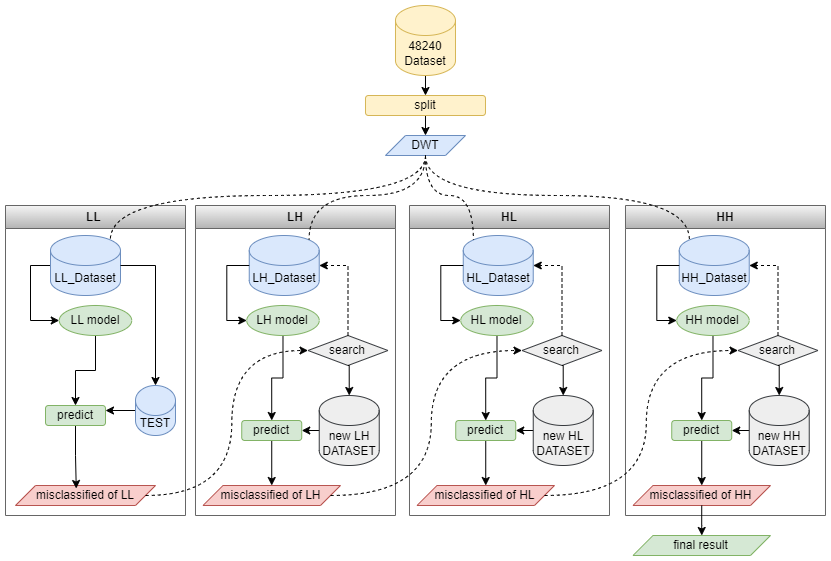

## 1.1. Naive-DWT-Ensemble on 48240 dataset (pretransformed DWT)
### works with versions 2.12 and 2.10 of tensorflow

In [ ]:

import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import numpy as np
#import tensorflow_decision_forests as tfdf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization,MaxPool2D
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
from keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from keras.callbacks import Callback
import os
import shutil
from shutil import copyfile
import time
import random as rn
print(tf.__version__)
start_time = time.time()
results = {}
COUNT = 0
TP_COUNT=0
TN_COUNT=0


#-------------
# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
setup_seed(42)
#------------

def print_results(dictionairy):
    print("--------------")
    # Calculate the maximum width for each field
    max_widths = {}
    for key, value in dictionairy.items():
        for field, val in value.items():
            val_str = f"{val:.5f}" if isinstance(val, float) else str(val)
            if field not in max_widths:
                max_widths[field] = len(val_str)
            else:
                max_widths[field] = max(max_widths[field], len(val_str))

    # Print the results with consistent spacing
    for key, value in dictionairy.items():
        print(f"'{key}': {{", end="")
        for field, val in value.items():
            val_str = f"{val:.5f}" if isinstance(val, float) else str(val)
            print(f"'{field}': {val_str:<{max_widths[field]}}", end=", ")
        print("}")

def run_region_pipeline(img_width, img_height,batch_size,epochs,learn_rate,option,region_count,region, datasets,all_regions_length, previous_misclassified_folder=None, previous_region=None):
    training_path, validation_path, test_folder = datasets
    last_FP, last_FN = 0, 0
    initial_TP, initial_TN = 0,0
    print(f"-----{region}-----")
    last_region=""
    first_region=""
    
    model,datagen = run_cnn(img_width, img_height,batch_size,epochs,learn_rate,option,training_path, validation_path, region)

    if region_count==all_regions_length:
        last_region = region
    elif region_count==1:
        first_region = region
    
    isinitial=False
    print(f"-----testing on the initial test dataset-----")
    
    if region_count== 1:
        isinitial=True
        misclassified_folder = f'misclassified_folder_{region}'
        initial_TP, initial_TN = testing(datagen,isinitial,test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    else:
        misclassified_folder = f'init_misclassified_folder_{region}'
        isinitial=True
        testing(datagen,isinitial,test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    # for inbetween accs for each region separately, this does not count for the transfer learning
    #testing(test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region)
    
    misclassified_folder = f'misclassified_folder_{region}'
    if previous_misclassified_folder:
        search_folder = test_folder
        validation_of_misclassified = f"misclassified_from_{previous_region}_to_{region}"
        test_path = transfer_misclassified_to_next_region(f"_{previous_region}", f"_{region}", previous_misclassified_folder, search_folder, validation_of_misclassified)
        print(f"-----testing misclassified of {previous_region} in {region}-----")
        if(region_count==all_regions_length):
            isinitial=False
            last_FP, last_FN = testing(datagen,isinitial,test_path, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
        else:
            isinitial=False
            testing(datagen,isinitial,test_path, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    else:
        last_FP, last_FN = 0, 0
    
    if region_count== 1:
        return model, initial_TP, initial_TN, misclassified_folder, last_FP, last_FN
    else:
        return model, misclassified_folder, last_FP, last_FN

def custom(img_width,img_height):
    # Creating model
    if K.image_data_format() == 'channels_first':
        input_shape = (3, img_width, img_height)
    else:
        input_shape = (img_width, img_height, 3)

    model = Sequential()

    # Reduce the size of the convolutional layers
    model.add(Conv2D(8,  (1, 1), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))
    
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))

    model.add(Conv2D(32, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    outputs = model.add(Dense(1, activation='sigmoid'))
    
    return model,outputs
    #"""

def mobile_netv3_small(img_width,img_height):
    from tensorflow.keras.applications import MobileNetV3Small
    #base_model = MobileNetV3Small(include_top=False, input_shape=(img_width,img_height, 3))
    base_model = MobileNetV3Small(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    # Freeze all layers in the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    return model, outputs 

def mobile_netv3_large(img_width,img_height):
    from tensorflow.keras.applications import MobileNetV3Large
    base_model = MobileNetV3Large(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    
    return model, outputs 

def efficientnet(img_width,img_height):
    from tensorflow.keras.applications import EfficientNetV2L
    #tf.keras.backend.set_image_data_format('channels_last')
    base_model = EfficientNetV2L(include_top=False, input_shape=(img_width,img_height, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Freeze the layers of the base model
    #for layer in base_model.layers:
    #    layer.trainable = False
    return model, outputs 
    
def res_net(img_width,img_height):
    from tensorflow.keras.applications.resnet_v2 import ResNet50V2
    base_model = ResNet50V2(input_shape=(img_width,img_height,3), include_top=False) # include top = false better for transfer learning
    # Freeze all layers in the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    
    return model, outputs

def xception(img_width,img_height):
    from tensorflow.keras.applications import Xception
    #base_model = Xception(input_shape=(img_width,img_height,3), include_top=False)
    base_model = Xception(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    #for layer in base_model.layers:
    #    layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    model.layers[-1].trainable = True
    return model, outputs

def dense_net(img_width,img_height):
    from tensorflow.keras.applications import DenseNet121
    # -- stock densenet121 model --
    base_model = DenseNet121(input_shape=(img_width, img_height, 3), include_top=False)
    #for layer in base_model.layers:
    #    layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    #model.layers[-1].trainable = True
    return model, outputs

def dense_net_201(img_width,img_height):
    from tensorflow.keras.applications import DenseNet201
    # -- stock densenet121 model --
    #base_model = DenseNet201(input_shape=(img_width, img_height, 3), include_top=False)
    base_model = DenseNet201(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    for layer in base_model.layers:
        layer.trainable = False
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    model.layers[-1].trainable = True
    return model, outputs

def inceptionv3(img_width,img_height):
    from tensorflow.keras.applications import InceptionV3
    # -- stock densenet121 model --
    base_model = InceptionV3(input_shape=(img_width, img_height, 3), include_top=False)
    #for layer in base_model.layers:
    #    layer.trainable = False
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    #model.layers[-1].trainable = True
    return model, outputs

def vgg16(img_width,img_height):
    from tensorflow.keras.applications import VGG16
    # -- stock densenet121 model --
    base_model = VGG16(input_shape=(img_width, img_height, 3), include_top=False)
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    return model, outputs

def random_forest(img_width,img_height):
    model = tfdf.keras.RandomForestModel()
    return model

def testing(datagen,isinitial,testing_path, model, imgWidth, imgHeight, batch_size, save_path, region_identifier,last_region,first_region,previous_region):
    global COUNT
    COUNT = COUNT+1
    global TP_COUNT
    global TN_COUNT
    
    TP,TN,FP,FN=0,0,0,0
    print(testing_path)
    if os.path.isdir(testing_path)==False:
        return FP,FN
    
    test_generator = datagen.flow_from_directory(
        testing_path, 
        target_size=(imgWidth, imgHeight), 
        batch_size=batch_size, 
        class_mode='binary', 
        shuffle=False)  # keep data in the same order as labels
    
    # Load best model
    model.load_weights(region_identifier+"_best_model.keras")
    # Predict classes
    Y_pred_test = model.predict(test_generator, test_generator.samples // test_generator.batch_size+1)
    test_labels = (Y_pred_test > 0.5).astype(int)
    filenames = test_generator.filenames
    #debug misclassified/classified samples
    #print("\n{:<60} | {:<12} | {:<6} | {:<14}".format('Filename', 'Prediction', 'Label', 'Status'))
    #print("{:<60} + {:<12} + {:<6} + {:<14}".format('-'*8, '-'*10, '-'*5, '-'*7))
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    else:
        shutil.rmtree(save_path)
    malwarepath = os.path.join(save_path, "Malware")
    softwarepath = os.path.join(save_path, "Software")
    os.makedirs(malwarepath, exist_ok=True)
    os.makedirs(softwarepath, exist_ok=True)
    
    misclassified_images = []  # Keeping track of misclassified images
    count = 0
    for i in range(len(filenames)):
        detection_status = "Software" if test_labels[i][0] == 1 else "Malware"
        #debug misclassified/classified samples
        #print(" "+"{:<60} | {:<12.6f} | {:<6d} | {:<14}".format(filenames[i], Y_pred_test[i][0], test_labels[i][0], detection_status))
        # Extract the folder from the path
        folder_path = os.path.dirname(filenames[i])

        #print("[+] folder path: ",folder_path," - detection_status: ",detection_status)
        # If the image is misclassified, add it to the list and copy it to the misclassified directory
        if folder_path != detection_status:
            # debugging print of misclassified
            #print(" "+"{:<60} | {:<12.6f} | {:<6d} | {:<14}".format(filenames[i], Y_pred_test[i][0], test_labels[i][0], detection_status))
            misclassified_images.append(filenames[i])
            # Construct the source and destination paths
            #print(filenames[i])
            src_path = os.path.join(testing_path, filenames[i])
            dst_path = os.path.join(save_path, filenames[i])
            shutil.copyfile(src_path, dst_path)
            #print(" src:",src_path,"\n"," dst:",dst_path)
            count = count + 1
        else:
            if isinitial == False:
                # TP = MALWARE = label -> 0, TN = SOFTWARE = label -> 1
                if detection_status == "Malware":
                    TP_COUNT = TP_COUNT+1
                else:
                    TN_COUNT = TN_COUNT+1

    #print("count:",count)
    print(test_generator.class_indices)
    cm = confusion_matrix(test_generator.classes, test_labels)
    print(cm)
    TN, FP, FN, TP = cm.ravel()
    print("[[TN FP]\n[FN TP]]")
    print(f"True Positives  (actual Software) (TP): {TP}")
    print(f"False Negatives (missed Software) (FN): {FN}")
    print(f"True Negatives  (actual Malware)  (TN): {TN}")
    print(f"False Positives (missed Malware)  (FP): {FP}")
    target_names = ['Malware','Software']
    print(classification_report(test_generator.classes, test_labels, zero_division=1, target_names=target_names, digits=5))
    report = classification_report(test_generator.classes, test_labels, digits=5, zero_division=1, output_dict=True)

    # Extract overall metrics, for a binary classification with 'class_0' and 'class_1', class_0 = malware, class_1 = software
    accuracy = report['accuracy']

    # Extract metrics for each class
    precision_class_0 = report['0']['precision']
    recall_class_0 = report['0']['recall']
    f1_score_class_0 = report['0']['f1-score']
    support_class_0 = report['0']['support']
    precision_class_1 = report['1']['precision']
    recall_class_1 = report['1']['recall']
    f1_score_class_1 = report['1']['f1-score']
    support_class_1 = report['1']['support']

    # Optionally extract macro/micro/weighted averages if available
    macro_avg_precision = report['macro avg']['precision']
    macro_avg_recall = report['macro avg']['recall']
    macro_avg_f1 = report['macro avg']['f1-score']
    weighted_avg_precision = report['weighted avg']['precision']
    weighted_avg_recall = report['weighted avg']['recall']
    weighted_avg_f1 = report['weighted avg']['f1-score']

    """
    # Print all the extracted metrics
    print(f"Accuracy: {accuracy}")

    print(f"\nClass 0 Metrics:")
    print(f"Precision: {precision_class_0}")
    print(f"Recall: {recall_class_0}")
    print(f"F1-Score: {f1_score_class_0}")
    print(f"Support: {support_class_0}")

    print(f"\nClass 1 Metrics:")
    print(f"Precision: {precision_class_1}")
    print(f"Recall: {recall_class_1}")
    print(f"F1-Score: {f1_score_class_1}")
    print(f"Support: {support_class_1}")

    print(f"\nMacro Average Metrics:")
    print(f"Precision: {macro_avg_precision}")
    print(f"Recall: {macro_avg_recall}")
    print(f"F1-Score: {macro_avg_f1}")

    print(f"\nWeighted Average Metrics:")
    print(f"Precision: {weighted_avg_precision}")
    print(f"Recall: {weighted_avg_recall}")
    print(f"F1-Score: {weighted_avg_f1}")
    """
    var="init"
    if isinitial==True:
        results[str(COUNT)+"_"+var+"   -> "+region_identifier] = {
            #"region": region_identifier,
             "TP": TP,
             "TN": TN,
             "FP": FP,
             "FN": FN,
             "test_acc": round(accuracy,5),
             "precision": round(macro_avg_precision,5),
             "recall": round(macro_avg_recall,5),
             "f1_score": round(macro_avg_f1,5)
        }
    else:
        results[str(COUNT)+"_"+str(previous_region)+"     -> "+region_identifier] = {
            #"region": region_identifier,
            "TP": TP,
            "TN": TN,
            "FP": FP,
            "FN": FN,
            "test_acc": round(accuracy,5),
            "precision": round(macro_avg_precision,5),
            "recall": round(macro_avg_recall,5),
            "f1_score": round(macro_avg_f1,5)
        }
    
    print("current region:",region_identifier)
    print("previous region: ",previous_region)
    
    for key,value in results.items():
        print(f"'{key}': {value},")
    
    if region_identifier == last_region:
        last_FN = cm[0][1]
        last_FP = cm[1][0]
        return last_FP,last_FN
    elif region_identifier == first_region:
        initial_TP = cm[0][0]
        initial_TN = cm[1][1]
        return initial_TP, initial_TN

def transfer_misclassified_to_next_region(previous_region,next_region,misclassified_folder,search_folder,validation_for_next_region):
    if not os.path.exists(validation_for_next_region):
        os.makedirs(validation_for_next_region)
    else:
        shutil.rmtree(validation_for_next_region)

    def extract_and_modify_filename(filename):
        extracted_string = filename.split(previous_region+".png")[0] # Extract the portion before "region.png"
        return extracted_string + next_region +".png"  # Append "next region" and return

    extracted_strings = [] # Create a list to store the extracted strings
    for root, _, files in os.walk(misclassified_folder):  # Walk through the misclassified folder
        for file in files:
            extracted_string = extract_and_modify_filename(file)
            #print("-> ",extracted_string)
            extracted_strings.append(extracted_string)
        
    print("misclassified samples length: ",len(extracted_strings))
    print("search folder: ",search_folder)
    # Walk through the search folder and copy matching files to the destination folder
    for root, _, files in os.walk(search_folder):
        for file in files:
            for extracted_string in extracted_strings:
                if extracted_string in file:
                    source_file_path = os.path.join(root, file)
                    destination_subfolder = os.path.join(validation_for_next_region, os.path.basename(root))
                    # Create the subfolder if it doesn't exist
                    if not os.path.exists(destination_subfolder):
                        os.makedirs(destination_subfolder)
                    # Copy the file to the appropriate subfolder
                    shutil.copy(source_file_path, os.path.join(destination_subfolder, file))

    return validation_for_next_region

def run_cnn(img_width, img_height,batch_size,epochs,learn_rate,option,training_path,validation_path,region_identifier):
    if (option=="densenet"):
        model,outputs = dense_net(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
    elif (option=="densenet_201"):
        model,outputs = dense_net_201(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
    elif (option=="resnet"):
        model,outputs = res_net(img_width,img_height)  
    elif (option=="mobile_netv3_small"):
        model,outputs = mobile_netv3_small(img_width,img_height)
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
    elif (option=="mobile_netv3_large"):
        model,outputs = mobile_netv3_large(img_width,img_height)
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
    elif (option=="efficientnet"):
        model,outputs = efficientnet(img_width,img_height)
    elif (option=="inceptionv3"):
        model,outputs = inceptionv3(img_width,img_height)
    elif (option=="custom"):
        model,outputs = custom(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
        #train_datagen = ImageDataGenerator(rescale=1. / 255)
        #valid_datagen = ImageDataGenerator(rescale=1. / 255)
    elif (option=="vgg16"):
        model,outputs = vgg16(img_width,img_height)
    elif (option=="xception"):
        from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=xception_preprocess_input)
        model,outputs = xception(img_width,img_height)
    
    model.compile(optimizer=Adam(learning_rate=learn_rate), loss='binary_crossentropy', metrics=['accuracy'])

    train_generator = datagen.flow_from_directory(
        training_path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True)

    valid_generator = datagen.flow_from_directory(
        validation_path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False)
    
    lr_schedule = ReduceLROnPlateau(
        monitor='val_loss',  # Monitor validation loss
        factor=0.3,            # Factor by which the learning rate will be reduced (new_lr = lr * factor)
        patience=3,            # Number of epochs with no improvement after which learning rate will be reduced
        verbose=1,             # Provide output about learning rate changes
        min_lr=1e-6            # Minimum learning rate (optional) (1e-6 = 0.000001)
    )
    
    Early_Stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        verbose=1,
        restore_best_weights='True',
        #min_delta=0.1
    )

    # Checkpoints
    checkpoint = ModelCheckpoint(region_identifier+"_best_model.keras", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    callbacks_list = [checkpoint,lr_schedule]

    # Training
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.n // batch_size,
        epochs=epochs,
        validation_data=valid_generator,
        validation_steps=valid_generator.n // batch_size,
        callbacks=[callbacks_list]
    )

    # Evaluating model
    model.load_weights(region_identifier+"_best_model.keras") # Loading best model
    valid_generator.reset()
    Y_pred = model.predict(valid_generator, valid_generator.n // batch_size + 1)
    y_pred = np.where(Y_pred > 0.5, 1, 0)
    cm = confusion_matrix(valid_generator.classes, y_pred)
    print('Confusion Matrix')
    print(cm)
    TN, FP, FN, TP = cm.ravel()
    print("[[TN FP]\n[FN TP]]")
    print(f"True Positives  (actual Software) (TP): {TP}")
    print(f"False Negatives (missed Software) (FN): {FN}")
    print(f"True Negatives  (actual Malware)  (TN): {TN}")
    print(f"False Positives (missed Malware)  (FP): {FP}")
    print('Classification Report')
    target_names = ['Malware', 'Software']
    print(f"\nimgWidth = {img_width}, imgHeight = {img_height}\nepochs = {epochs}\nbatch size = {batch_size}\nlearning rate = {learn_rate}")
    #model.summary()
    print(classification_report(valid_generator.classes, y_pred, target_names=target_names,zero_division=1,digits=5))
    
    # Plot training and validation loss and learning rate side by side
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
    # Plot Training and Validation Loss
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    # Plot Learning Rate
    axes[1].plot(history.history['lr'], label='Learning Rate', color='red')
    axes[1].set_title('Learning Rate')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Learning Rate')
    axes[1].legend()
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

    return model,datagen

#------------------ main ----------
start_time = time.time()

#img_width, img_height = 32,32
#batch_size = 64
#epochs = 1
#learn_rate = 0.001
#learn_rate = 0.0001 #-> good for epochs = 15 and higher, 25epochs -> 85 tescc
#learn_rate = 0.000001
#option="resnet"
#option="densenet"
#option="densenet_201"
#option="mobile_netv3_small"
#option="efficientnet"
#option="custom"
#option="inceptionv3"
#option="vgg16"
#option="mobile_netv3_large"
#option="xception"

# Define datasets for each region
#"""
datasets_dict = {
    "LL": ['/kaggle/input/data-48240-db2-lvl1-ll-60-15-25/Data_48240_db2_lvl1_LL_60_15_25/Training',
           '/kaggle/input/data-48240-db2-lvl1-ll-60-15-25/Data_48240_db2_lvl1_LL_60_15_25/Validation',
           '/kaggle/input/data-48240-db2-lvl1-ll-60-15-25/Data_48240_db2_lvl1_LL_60_15_25/Test'],
    "LH": ['/kaggle/input/data-48240-db2-lvl1-lh-60-15-25/Data_48240_db2_lvl1_LH_60_15_25/Training',
           '/kaggle/input/data-48240-db2-lvl1-lh-60-15-25/Data_48240_db2_lvl1_LH_60_15_25/Validation',
           '/kaggle/input/data-48240-db2-lvl1-lh-60-15-25/Data_48240_db2_lvl1_LH_60_15_25/Test'],
    "HL": ['/kaggle/input/data-48240-db2-lvl1-hl-60-15-25/Data_48240_db2_lvl1_HL_60_15_25/Training',
           '/kaggle/input/data-48240-db2-lvl1-hl-60-15-25/Data_48240_db2_lvl1_HL_60_15_25/Validation',
           '/kaggle/input/data-48240-db2-lvl1-hl-60-15-25/Data_48240_db2_lvl1_HL_60_15_25/Test'],
    "HH": ['/kaggle/input/data-48240-db2-lvl1-hh-60-15-25/Data_48240_db2_lvl1_HH_60_15_25/Training',
           '/kaggle/input/data-48240-db2-lvl1-hh-60-15-25/Data_48240_db2_lvl1_HH_60_15_25/Validation',
           '/kaggle/input/data-48240-db2-lvl1-hh-60-15-25/Data_48240_db2_lvl1_HH_60_15_25/Test']
}
#"""

#regions = ["LL","LL","LL","LL"] 
regions = ["LL","LH","HL","HH"] 
# TODO NEXT BELOW
#regions = ["LL", "LH", "HL", "HH","LL", "LH", "HL", "HH","LL", "LH", "HL", "HH"]
model0 = {"model": ["densenet"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model1 = {"model": ["densenet_201"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model2 = {"model": ["xception"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model3 = {"model": ["resnet"],"epochs": [1],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model4 = {"model": ["inceptionv3"],"epochs": [1],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}

#--------------
regions = ["LL","LH","HL","HH"] 
model5 = {"model": ["mobile_netv3_large"],"epochs": [30],"learn_rate": [0.01],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model6 = {"model": ["mobile_netv3_small"],"epochs": [30],"learn_rate": [0.01],"batch_size" : [64],"img_width": [128],"img_height": [128]}

model7 = {"model": ["custom"],"epochs": [1],"learn_rate": [0.01],"batch_size" : [64],"img_width": [128],"img_height": [128]}

#models_to_train = [model4,model1,model2,model3]
# TODO NEXT BELOW
models_to_train = [model7,model7,model7,model7]

for i in models_to_train:
    print(i)
all_regions_length = len(regions)
print("all regions count: ",all_regions_length)
# manage regions at first gets initial_TP, initial_TN, and in the end of the procedure we get the last_FP, last_FN which is what we need for the final confusion matrix and final classification report
initial_TP, initial_TN, last_FP, last_FN = 0, 0, 0, 0
previous_misclassified_folder = None
previous_region = None
region_count = 0
models_index = 0
for region in regions:
    region_count = region_count + 1
    dataset = datasets_dict[region]
    if (region_count==1):
        #models_to_train[models_index]["img_width"], models_to_train[models_index]["img_height"],models_to_train[models_index]["batch_size"],models_to_train[models_index]["epochs"],models_to_train[models_index]["learn_rate"],models_to_train[models_index]["model"][0]
        
        model, initial_TP, initial_TN, previous_misclassified_folder, last_FP, last_FN = run_region_pipeline(
            models_to_train[models_index]["img_width"][0], models_to_train[models_index]["img_height"][0],models_to_train[models_index]["batch_size"][0],models_to_train[models_index]["epochs"][0],models_to_train[models_index]["learn_rate"][0],models_to_train[models_index]["model"][0],region_count,region, dataset,all_regions_length, previous_misclassified_folder, previous_region)
        models_index = models_index +1 
    else:
        model, previous_misclassified_folder, last_FP, last_FN = run_region_pipeline(
            models_to_train[models_index]["img_width"][0], models_to_train[models_index]["img_height"][0],models_to_train[models_index]["batch_size"][0],models_to_train[models_index]["epochs"][0],models_to_train[models_index]["learn_rate"][0],models_to_train[models_index]["model"][0],region_count,region, dataset,all_regions_length, previous_misclassified_folder, previous_region)
        models_index = models_index +1 
    previous_region = region

# Generate the overall report
last_TP = initial_TP + TP_COUNT
last_TN = initial_TN + TN_COUNT
print("-------------[ OVERALL REPORT ]--------------")
final_confusion_matrix = tf.constant([[last_TN, last_FP],
                  [last_FN, last_TP]])
print(final_confusion_matrix)
print("Final True Positives   (actual Software): ", last_TN)
print("Final True Negatives   (actual Malware) : ", last_TP)
print("Final False Negatives: (missed Software): ", last_FP)
print("Final False Positives: (missed Malware) : ", last_FN)
#final_confusion_matrix = np.array([[last_TP, last_FP], [last_FN, last_TN]])
#print(final_confusion_matrix)

# Calculate precision, recall, and f1-score for Malware class
precision_malware = last_TP / (last_TP + last_FP)
recall_malware = last_TP / (last_TP + last_FN)
f1_score_malware = 2 * (precision_malware * recall_malware) / (precision_malware + recall_malware)
# Calculate precision, recall, and f1-score for Software class
precision_software = last_TN / (last_TN + last_FN)
recall_software = last_TN / (last_TN + last_FP)
f1_score_software = 2 * (precision_software * recall_software) / (precision_software + recall_software)
print('Classification Report')
print('                    precision    recall    f1-score   support')
print()
print('     Malware       {:.5f}      {:.5f}      {:.5f}       {}'.format(precision_malware, recall_malware, f1_score_malware, np.sum(final_confusion_matrix[0, :])))
print('     Software      {:.5f}      {:.5f}      {:.5f}       {}'.format(precision_software, recall_software, f1_score_software, np.sum(final_confusion_matrix[1, :])))
print()
accuracy = (last_TP + last_TN) / np.sum(final_confusion_matrix)
print('    accuracy                                 {:.5f}    {}'.format(accuracy, np.sum(final_confusion_matrix)))
print('   macro avg       {:.5f}      {:.5f}      {:.5f}       {}'.format((precision_malware + precision_software) / 2, (recall_malware + recall_software) / 2, (f1_score_malware + f1_score_software) / 2, np.sum(final_confusion_matrix)))
print('weighted avg       {:.5f}      {:.5f}      {:.5f}       {}'.format((last_TP * precision_malware + last_TN * precision_software) / np.sum(final_confusion_matrix), (last_TP * recall_malware + last_TN * recall_software) / np.sum(final_confusion_matrix), (last_TP * f1_score_malware + last_TN * f1_score_software) / np.sum(final_confusion_matrix), np.sum(final_confusion_matrix)))

#macro avg
macro_avg_precision = (precision_malware + precision_software) / 2
macro_avg_recall = (recall_malware + recall_software) / 2
macro_avg_f1_score = (f1_score_malware + f1_score_software) / 2
# insert the final results in the dictionairy
results["final         "] = {
    #"region": region_identifier,
    "TP": last_TP,
    "TN": last_TN,
    "FP": last_FP,
    "FN": last_FN,
    "test_acc": round(accuracy,5),
    "precision": round(macro_avg_precision,5),
    "recall": round(macro_avg_recall,5),
    "f1_score": round(macro_avg_f1_score,5)
    #"init_test_acc": 
}

print("\n")
#print("model: ",option)
#print("epochs: ",epochs)
# print the whole dictionary 
#for key,value in results.items():
#    print(f"'{key}': {value},")

for i in models_to_train:
    print(i)

print_results(results)

# Calculate elapsed runtime
end_time = time.time()
runtime_seconds = end_time - start_time
runtime_minutes = runtime_seconds / 60
runtime_hours = runtime_minutes / 60
print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")

## 1.2. Naive-DWT-Ensemble on 913 dataset (pretransformed DWT)

2.10.0
{'model': ['custom'], 'epochs': [5], 'learn_rate': [0.001], 'batch_size': [64], 'img_width': [32], 'img_height': [32]}
{'model': ['custom'], 'epochs': [5], 'learn_rate': [0.001], 'batch_size': [64], 'img_width': [32], 'img_height': [32]}
{'model': ['custom'], 'epochs': [5], 'learn_rate': [0.001], 'batch_size': [64], 'img_width': [32], 'img_height': [32]}
{'model': ['custom'], 'epochs': [5], 'learn_rate': [0.001], 'batch_size': [64], 'img_width': [32], 'img_height': [32]}
all regions count:  4
-----LL-----
Found 696 images belonging to 2 classes.
Found 172 images belonging to 2 classes.
Epoch 1/5
10/10 [==============================] - ETA: 0s - loss: 0.5899 - accuracy: 0.7468
Epoch 1: val_loss improved from inf to 0.68771, saving model to LL_best_model.keras
10/10 [==============================] - 4s 338ms/step - loss: 0.5899 - accuracy: 0.7468 - val_loss: 0.6877 - val_accuracy: 0.6406 - lr: 0.0010
Epoch 2/5
10/10 [==============================] - ETA: 0s - loss: 0.3682 - acc

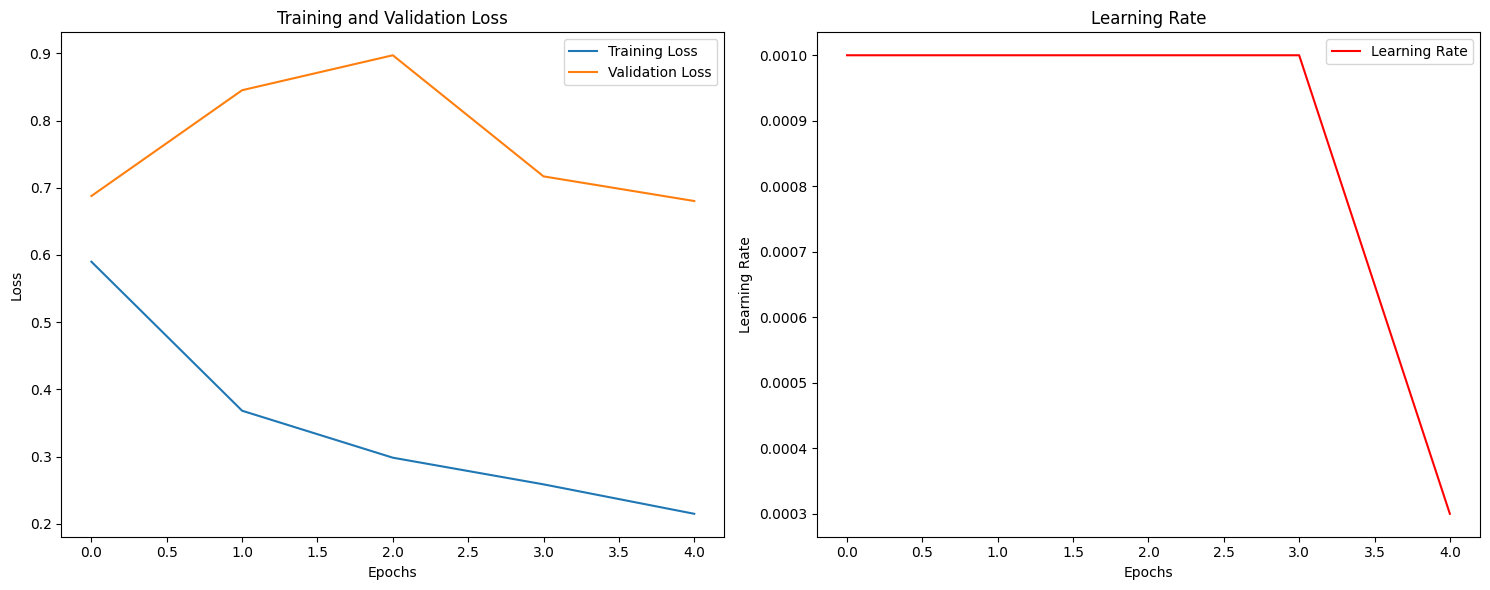

-----testing on the initial test dataset-----
/kaggle/input/data913-80-20-db2-lvl1-ll/data913_80_20_db2_lvl1_LL/Test
Found 13 images belonging to 1 classes.
1/1 [==============================] - 0s 196ms/step
{'malware': 0}
------------------
Undetected       - [1] - 0.69195586  -  malware/0day_LL.png
Undetected       - [1] - 0.67329407  -  malware/blackEnergy_LL.png
Undetected       - [1] - 0.74603623  -  malware/distcc_exec_backdoor_LL.png
Undetected       - [1] - 0.60892391  -  malware/hydra_ftp_LL.png
Undetected       - [1] - 0.60880852  -  malware/hydra_ssh_LL.png
Undetected       - [1] - 0.63908392  -  malware/java_rmi_LL.png
Undetected       - [1] - 0.77365756  -  malware/mirai_LL.png
Undetected       - [1] - 0.61187762  -  malware/netbios_ssn_LL.png
Undetected       - [1] - 0.67147881  -  malware/ruby_drb_LL.png
Undetected       - [1] - 0.67466384  -  malware/smtp_LL.png
Detected Malware - [0] - 0.38881388  -  malware/tomcat_LL.png
Undetected       - [1] - 0.68046671  -  malwa

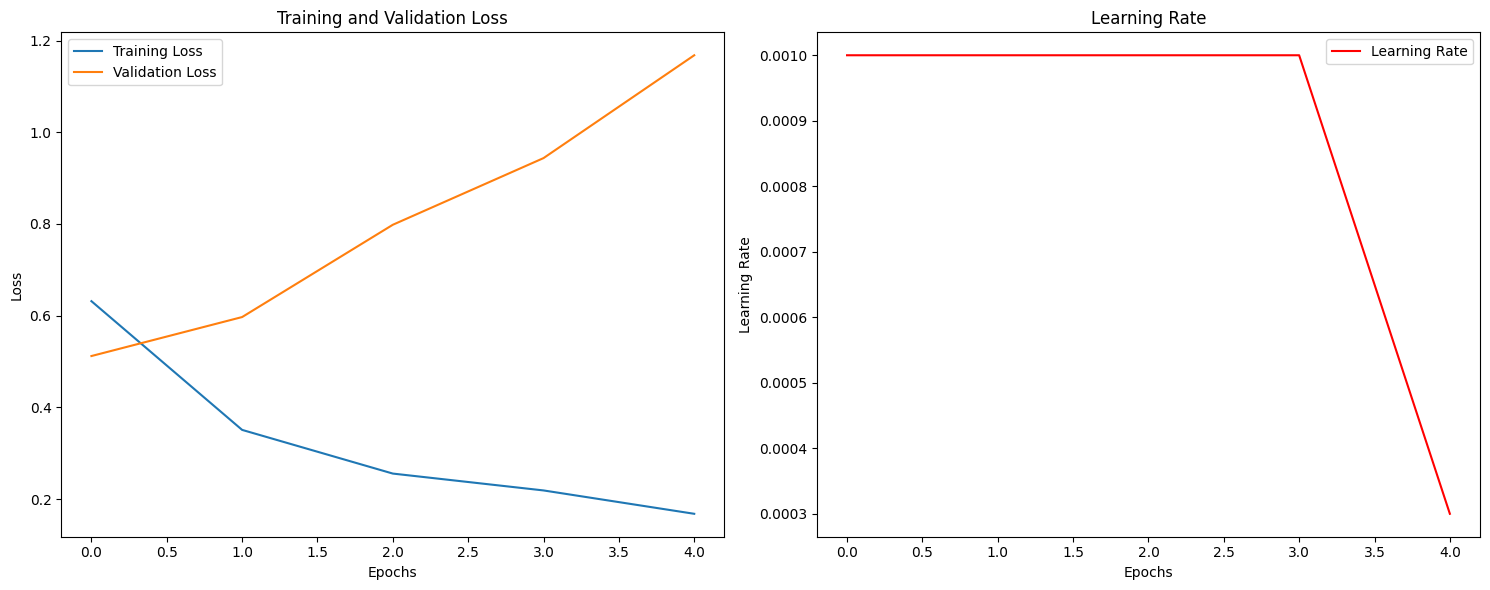

-----testing on the initial test dataset-----
/kaggle/input/data913-80-20-db2-lvl1-lh/data913_80_20_db2_lvl1_LH/Test
Found 13 images belonging to 1 classes.
1/1 [==============================] - 0s 149ms/step
{'malware': 0}
------------------
Detected Malware - [0] - 0.46156293  -  malware/0day_LH.png
Detected Malware - [0] - 0.49462453  -  malware/blackEnergy_LH.png
Undetected       - [1] - 0.53434420  -  malware/distcc_exec_backdoor_LH.png
Detected Malware - [0] - 0.29329258  -  malware/hydra_ftp_LH.png
Detected Malware - [0] - 0.35008228  -  malware/hydra_ssh_LH.png
Detected Malware - [0] - 0.35351935  -  malware/java_rmi_LH.png
Undetected       - [1] - 0.50867987  -  malware/mirai_LH.png
Detected Malware - [0] - 0.35975534  -  malware/netbios_ssn_LH.png
Detected Malware - [0] - 0.34007204  -  malware/ruby_drb_LH.png
Detected Malware - [0] - 0.45288771  -  malware/smtp_LH.png
Detected Malware - [0] - 0.33269125  -  malware/tomcat_LH.png
Detected Malware - [0] - 0.36770064  -  malwa

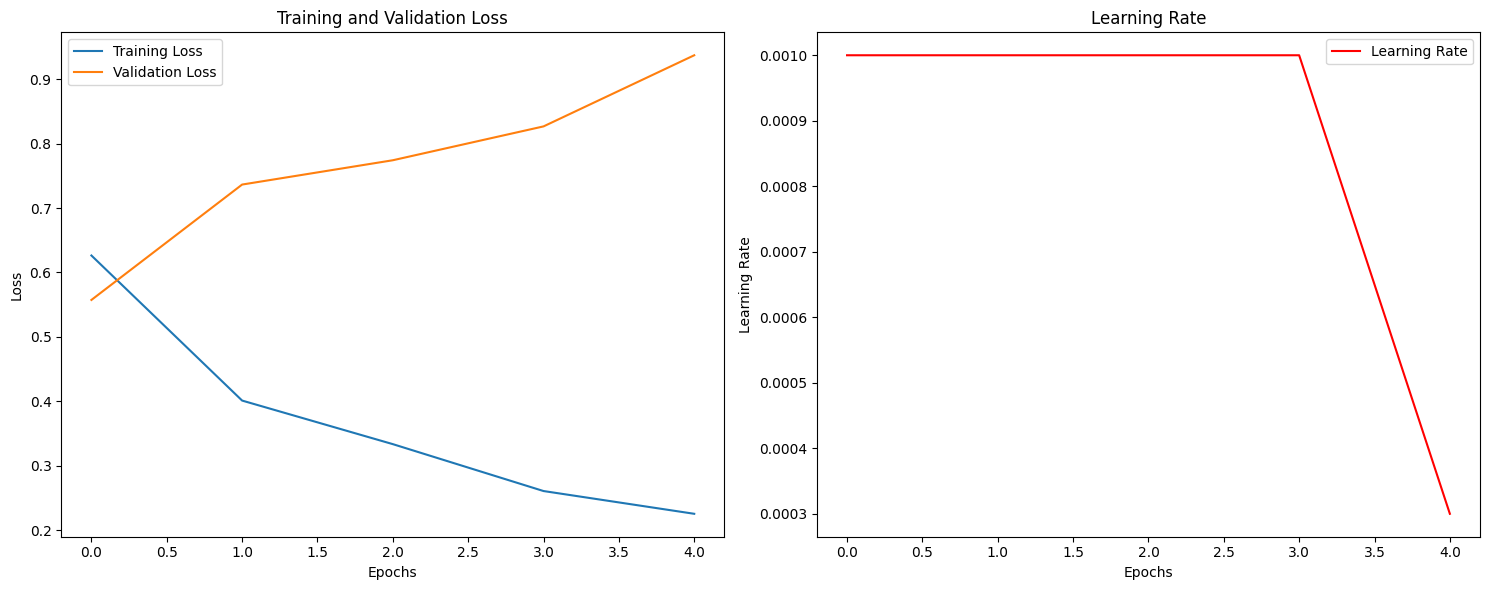

-----testing on the initial test dataset-----
/kaggle/input/data913-80-20-db2-lvl1-hl/data913_80_20_db2_lvl1_HL/Test
Found 13 images belonging to 1 classes.
1/1 [==============================] - 0s 163ms/step
{'malware': 0}
------------------
Detected Malware - [0] - 0.43134293  -  malware/0day_HL.png
Detected Malware - [0] - 0.41657370  -  malware/blackEnergy_HL.png
Detected Malware - [0] - 0.40234545  -  malware/distcc_exec_backdoor_HL.png
Detected Malware - [0] - 0.29739043  -  malware/hydra_ftp_HL.png
Detected Malware - [0] - 0.31595531  -  malware/hydra_ssh_HL.png
Detected Malware - [0] - 0.33826727  -  malware/java_rmi_HL.png
Detected Malware - [0] - 0.42563766  -  malware/mirai_HL.png
Detected Malware - [0] - 0.33633646  -  malware/netbios_ssn_HL.png
Detected Malware - [0] - 0.35960248  -  malware/ruby_drb_HL.png
Detected Malware - [0] - 0.39702874  -  malware/smtp_HL.png
Detected Malware - [0] - 0.41302460  -  malware/tomcat_HL.png
Detected Malware - [0] - 0.33157551  -  malwa

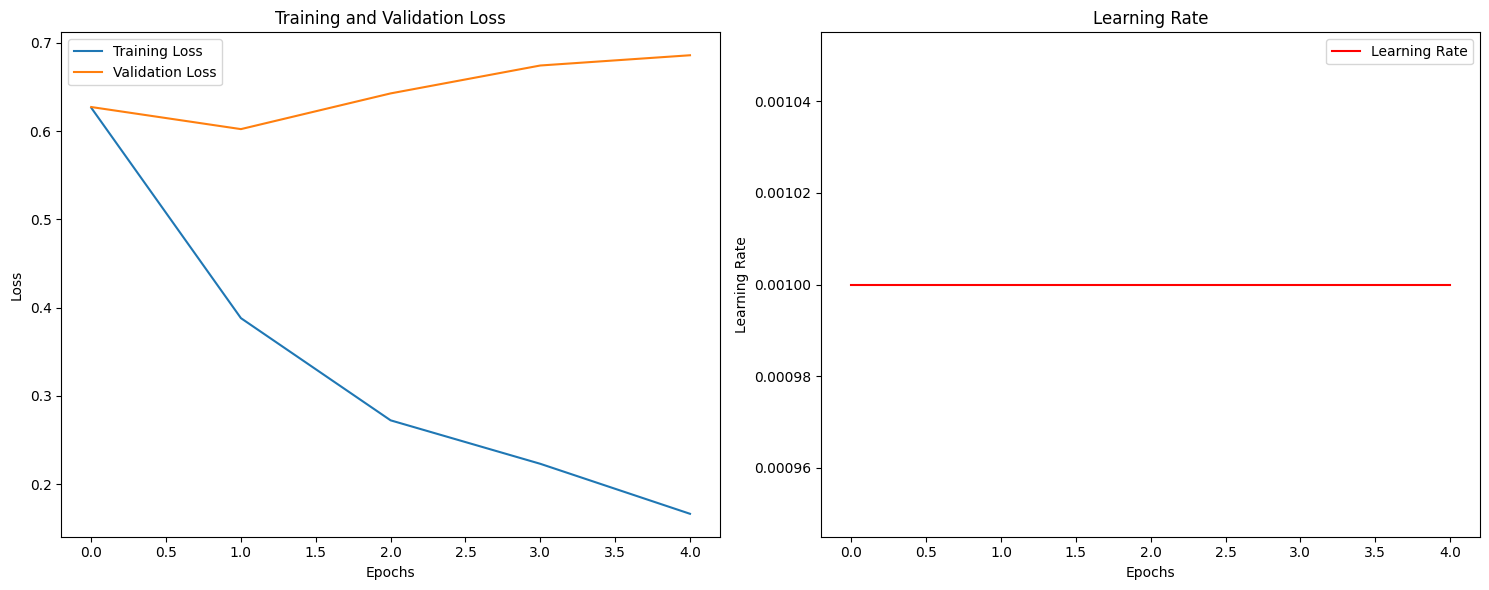

-----testing on the initial test dataset-----
/kaggle/input/data913-80-20-db2-lvl1-hh/data913_80_20_db2_lvl1_HH/Test
Found 13 images belonging to 1 classes.
1/1 [==============================] - 0s 137ms/step
{'malware': 0}
------------------
Detected Malware - [0] - 0.46565309  -  malware/0day_HH.png
Detected Malware - [0] - 0.48154676  -  malware/blackEnergy_HH.png
Detected Malware - [0] - 0.46454802  -  malware/distcc_exec_backdoor_HH.png
Detected Malware - [0] - 0.39818591  -  malware/hydra_ftp_HH.png
Detected Malware - [0] - 0.41220719  -  malware/hydra_ssh_HH.png
Detected Malware - [0] - 0.42293021  -  malware/java_rmi_HH.png
Detected Malware - [0] - 0.49038374  -  malware/mirai_HH.png
Detected Malware - [0] - 0.41238415  -  malware/netbios_ssn_HH.png
Detected Malware - [0] - 0.40633252  -  malware/ruby_drb_HH.png
Detected Malware - [0] - 0.42472661  -  malware/smtp_HH.png
Detected Malware - [0] - 0.41210157  -  malware/tomcat_HH.png
Detected Malware - [0] - 0.44690198  -  malwa

In [2]:

import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import numpy as np
#import tensorflow_decision_forests as tfdf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization,MaxPool2D
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
from keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from keras.callbacks import Callback
import os
import shutil
from shutil import copyfile
import time
import random as rn
print(tf.__version__)
start_time = time.time()
results = {}
COUNT = 0
TP_COUNT=0
TN_COUNT=0


#-------------
# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
setup_seed(42)
#------------

def print_results(dictionairy):
    print("--------------")
    # Calculate the maximum width for each field
    max_widths = {}
    for key, value in dictionairy.items():
        for field, val in value.items():
            val_str = f"{val:.5f}" if isinstance(val, float) else str(val)
            if field not in max_widths:
                max_widths[field] = len(val_str)
            else:
                max_widths[field] = max(max_widths[field], len(val_str))

    # Print the results with consistent spacing
    for key, value in dictionairy.items():
        print(f"'{key}': {{", end="")
        for field, val in value.items():
            val_str = f"{val:.5f}" if isinstance(val, float) else str(val)
            print(f"'{field}': {val_str:<{max_widths[field]}}", end=", ")
        print("}")

def run_region_pipeline(img_width, img_height,batch_size,epochs,learn_rate,option,region_count,region, datasets,all_regions_length, previous_misclassified_folder=None, previous_region=None):
    training_path, validation_path, test_folder = datasets
    last_FP, last_FN = 0, 0
    initial_TP, initial_TN = 0,0
    print(f"-----{region}-----")
    last_region=""
    first_region=""
    
    model,datagen = run_cnn(img_width, img_height,batch_size,epochs,learn_rate,option,training_path, validation_path, region)

    if region_count==all_regions_length:
        last_region = region
    elif region_count==1:
        first_region = region
    
    isinitial=False
    print(f"-----testing on the initial test dataset-----")
    
    if region_count== 1:
        isinitial=True
        misclassified_folder = f'misclassified_folder_{region}'
        initial_TP, initial_TN = testing(datagen,isinitial,test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    else:
        misclassified_folder = f'init_misclassified_folder_{region}'
        isinitial=True
        testing(datagen,isinitial,test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    # for inbetween accs for each region separately, this does not count for the transfer learning
    #testing(test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region)
    
    misclassified_folder = f'misclassified_folder_{region}'
    if previous_misclassified_folder:
        search_folder = test_folder
        validation_of_misclassified = f"misclassified_from_{previous_region}_to_{region}"
        test_path = transfer_misclassified_to_next_region(f"_{previous_region}", f"_{region}", previous_misclassified_folder, search_folder, validation_of_misclassified)
        print(f"-----testing misclassified of {previous_region} in {region}-----")
        if(region_count==all_regions_length):
            isinitial=False
            last_FP, last_FN = testing(datagen,isinitial,test_path, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
        else:
            isinitial=False
            testing(datagen,isinitial,test_path, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    else:
        last_FP, last_FN = 0, 0
    
    if region_count== 1:
        return model, initial_TP, initial_TN, misclassified_folder, last_FP, last_FN
    else:
        return model, misclassified_folder, last_FP, last_FN

def custom(img_width,img_height):
    # Creating model
    if K.image_data_format() == 'channels_first':
        input_shape = (3, img_width, img_height)
    else:
        input_shape = (img_width, img_height, 3)

    model = Sequential()

    # Reduce the size of the convolutional layers
    model.add(Conv2D(8,  (1, 1), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))
    
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))

    model.add(Conv2D(32, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    outputs = model.add(Dense(1, activation='sigmoid'))
    
    return model,outputs
    #"""

def mobile_netv3_small(img_width,img_height):
    from tensorflow.keras.applications import MobileNetV3Small
    #base_model = MobileNetV3Small(include_top=False, input_shape=(img_width,img_height, 3))
    base_model = MobileNetV3Small(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    # Freeze all layers in the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    return model, outputs 

def mobile_netv3_large(img_width,img_height):
    from tensorflow.keras.applications import MobileNetV3Large
    base_model = MobileNetV3Large(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    
    return model, outputs 

def efficientnet(img_width,img_height):
    from tensorflow.keras.applications import EfficientNetV2L
    #tf.keras.backend.set_image_data_format('channels_last')
    base_model = EfficientNetV2L(include_top=False, input_shape=(img_width,img_height, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Freeze the layers of the base model
    #for layer in base_model.layers:
    #    layer.trainable = False
    return model, outputs 
    
def res_net(img_width,img_height):
    from tensorflow.keras.applications.resnet_v2 import ResNet50V2
    base_model = ResNet50V2(input_shape=(img_width,img_height,3), include_top=False) # include top = false better for transfer learning
    # Freeze all layers in the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    
    return model, outputs

def xception(img_width,img_height):
    from tensorflow.keras.applications import Xception
    #base_model = Xception(input_shape=(img_width,img_height,3), include_top=False)
    base_model = Xception(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    #for layer in base_model.layers:
    #    layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    model.layers[-1].trainable = True
    return model, outputs

def dense_net(img_width,img_height):
    from tensorflow.keras.applications import DenseNet121
    # -- stock densenet121 model --
    base_model = DenseNet121(input_shape=(img_width, img_height, 3), include_top=False)
    #for layer in base_model.layers:
    #    layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    #model.layers[-1].trainable = True
    return model, outputs

def dense_net_201(img_width,img_height):
    from tensorflow.keras.applications import DenseNet201
    # -- stock densenet121 model --
    #base_model = DenseNet201(input_shape=(img_width, img_height, 3), include_top=False)
    base_model = DenseNet201(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    for layer in base_model.layers:
        layer.trainable = False
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    model.layers[-1].trainable = True
    return model, outputs

def inceptionv3(img_width,img_height):
    from tensorflow.keras.applications import InceptionV3
    # -- stock densenet121 model --
    base_model = InceptionV3(input_shape=(img_width, img_height, 3), include_top=False)
    #for layer in base_model.layers:
    #    layer.trainable = False
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    #model.layers[-1].trainable = True
    return model, outputs

def vgg16(img_width,img_height):
    from tensorflow.keras.applications import VGG16
    # -- stock densenet121 model --
    base_model = VGG16(input_shape=(img_width, img_height, 3), include_top=False)
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    return model, outputs

def random_forest(img_width,img_height):
    model = tfdf.keras.RandomForestModel()
    return model

def testing(datagen,isinitial,testing_path, model, imgWidth, imgHeight, batch_size, save_path, region_identifier,last_region,first_region,previous_region):
    global COUNT
    COUNT = COUNT+1
    global TP_COUNT
    global TN_COUNT
    
    TP,TN,FP,FN=0,0,0,0
    print(testing_path)
    if os.path.isdir(testing_path)==False:
        return FP,FN
    
    test_generator = datagen.flow_from_directory(
        testing_path, 
        target_size=(imgWidth, imgHeight), 
        batch_size=batch_size, 
        class_mode='binary', 
        shuffle=False)  # keep data in the same order as labels
    
    # Load best model
    model.load_weights(region_identifier+"_best_model.keras")
    if test_generator:
        # Predict classes
        Y_pred_test = model.predict(test_generator, test_generator.samples // test_generator.batch_size+1)
        test_labels = (Y_pred_test > 0.5).astype(int)
        filenames = test_generator.filenames
        #debug misclassified/classified samples
        #print("\n{:<60} | {:<12} | {:<6} | {:<14}".format('Filename', 'Prediction', 'Label', 'Status'))
        #print("{:<60} + {:<12} + {:<6} + {:<14}".format('-'*8, '-'*10, '-'*5, '-'*7))

    if not os.path.exists(save_path):
        os.makedirs(save_path)
    else:
        shutil.rmtree(save_path)
    malwarepath = os.path.join(save_path, "malware")
    softwarepath = os.path.join(save_path, "software")
    os.makedirs(malwarepath, exist_ok=True)
    os.makedirs(softwarepath, exist_ok=True)

    if test_generator:
        misclassified_images = []  # Keeping track of misclassified images
        count = 0
        for i in range(len(filenames)):
            detection_status = "software" if test_labels[i][0] == 1 else "malware"
            #debug misclassified/classified samples
            #print(" "+"{:<60} | {:<12.6f} | {:<6d} | {:<14}".format(filenames[i], Y_pred_test[i][0], test_labels[i][0], detection_status))
            # Extract the folder from the path
            folder_path = os.path.dirname(filenames[i])
            #print(f"detection_status: {detection_status}, folder_path: {folder_path}")
    
            #print("[+] folder path: ",folder_path," - detection_status: ",detection_status)
            # If the image is misclassified, add it to the list and copy it to the misclassified directory
            if folder_path != detection_status:
                # debugging print of misclassified
                #print(" "+"{:<60} | {:<12.6f} | {:<6d} | {:<14}".format(filenames[i], Y_pred_test[i][0], test_labels[i][0], detection_status))
                misclassified_images.append(filenames[i])
                # Construct the source and destination paths
                #print(filenames[i])
                src_path = os.path.join(testing_path, filenames[i])
                dst_path = os.path.join(save_path, filenames[i])
                shutil.copyfile(src_path, dst_path)
                #print(" src:",src_path,"\n"," dst:",dst_path)
                count = count + 1
            else:
                if isinitial == False:
                    # TP = MALWARE = label -> 0, TN = SOFTWARE = label -> 1
                    if detection_status == "Malware":
                        TP_COUNT = TP_COUNT+1
                    else:
                        TN_COUNT = TN_COUNT+1

        y_pred_test_model = model.predict(test_generator, test_generator.n // batch_size + 1)
        Y_pred_test = y_pred_test_model
        y_pred_test_model = np.where(y_pred_test_model > 0.5, 1, 0)
        #cm = confusion_matrix(test_generator.classes, test_labels)
        #print(cm)
        #print("test_labels: ",test_labels)
        test_labels = y_pred_test_model
        print(test_generator.class_indices)
        summ = 0 
        print("------------------")
        for i in range (0,len(test_generator.filenames)):
            detection_status = "Undetected      " if y_pred_test_model[i] > 0.5 else "Detected Malware"
            print(detection_status,"-",test_labels[i],"-","{:.8f}".format(Y_pred_test[i][0])," - ",test_generator.filenames[i])
            summ = summ + Y_pred_test[i][0]
        print("------------------")
        print("-> Avg malware accuracy: ",summ/13)

        

        var="init"
        if isinitial==True:
            results[str(COUNT)+"_"+var+"   -> "+region_identifier] = {
                #"region": region_identifier,
                "misclassified": count,
                "avg_acc": summ/13
            }
        else:
            results[str(COUNT)+"_"+str(previous_region)+"     -> "+region_identifier] = {
                #"region": region_identifier,
                "misclassified": count,
                "avg_acc": summ/13
            }

    if region_identifier == last_region:
        last_FN = -1
        last_FP = -1
        return last_FP,last_FN
    elif region_identifier == first_region:
        initial_TP = -1
        initial_TN = -1
        return initial_TP, initial_TN

def transfer_misclassified_to_next_region(previous_region,next_region,misclassified_folder,search_folder,validation_for_next_region):
    if not os.path.exists(validation_for_next_region):
        os.makedirs(validation_for_next_region)
    else:
        shutil.rmtree(validation_for_next_region)

    def extract_and_modify_filename(filename):
        extracted_string = filename.split(previous_region+".png")[0] # Extract the portion before "region.png"
        return extracted_string + next_region +".png"  # Append "next region" and return

    extracted_strings = [] # Create a list to store the extracted strings
    for root, _, files in os.walk(misclassified_folder):  # Walk through the misclassified folder
        for file in files:
            extracted_string = extract_and_modify_filename(file)
            #print("-> ",extracted_string)
            extracted_strings.append(extracted_string)
        
    print("misclassified samples length: ",len(extracted_strings))
    print("search folder: ",search_folder)
    # Walk through the search folder and copy matching files to the destination folder
    for root, _, files in os.walk(search_folder):
        for file in files:
            for extracted_string in extracted_strings:
                if extracted_string in file:
                    source_file_path = os.path.join(root, file)
                    destination_subfolder = os.path.join(validation_for_next_region, os.path.basename(root))
                    # Create the subfolder if it doesn't exist
                    if not os.path.exists(destination_subfolder):
                        os.makedirs(destination_subfolder)
                    # Copy the file to the appropriate subfolder
                    shutil.copy(source_file_path, os.path.join(destination_subfolder, file))

    return validation_for_next_region

def run_cnn(img_width, img_height,batch_size,epochs,learn_rate,option,training_path,validation_path,region_identifier):
    if (option=="densenet"):
        model,outputs = dense_net(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
    elif (option=="densenet_201"):
        model,outputs = dense_net_201(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
    elif (option=="resnet"):
        model,outputs = res_net(img_width,img_height)  
    elif (option=="mobile_netv3_small"):
        model,outputs = mobile_netv3_small(img_width,img_height)
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
    elif (option=="mobile_netv3_large"):
        model,outputs = mobile_netv3_large(img_width,img_height)
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
    elif (option=="efficientnet"):
        model,outputs = efficientnet(img_width,img_height)
    elif (option=="inceptionv3"):
        model,outputs = inceptionv3(img_width,img_height)
    elif (option=="custom"):
        model,outputs = custom(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
        #train_datagen = ImageDataGenerator(rescale=1. / 255)
        #valid_datagen = ImageDataGenerator(rescale=1. / 255)
    elif (option=="vgg16"):
        model,outputs = vgg16(img_width,img_height)
    elif (option=="xception"):
        from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=xception_preprocess_input)
        model,outputs = xception(img_width,img_height)
    
    model.compile(optimizer=Adam(learning_rate=learn_rate), loss='binary_crossentropy', metrics=['accuracy'])

    train_generator = datagen.flow_from_directory(
        training_path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True)

    valid_generator = datagen.flow_from_directory(
        validation_path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False)
    
    lr_schedule = ReduceLROnPlateau(
        monitor='val_loss',  # Monitor validation loss
        factor=0.3,            # Factor by which the learning rate will be reduced (new_lr = lr * factor)
        patience=3,            # Number of epochs with no improvement after which learning rate will be reduced
        verbose=1,             # Provide output about learning rate changes
        min_lr=1e-6            # Minimum learning rate (optional) (1e-6 = 0.000001)
    )
    
    Early_Stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        verbose=1,
        restore_best_weights='True',
        #min_delta=0.1
    )

    # Checkpoints
    checkpoint = ModelCheckpoint(region_identifier+"_best_model.keras", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    callbacks_list = [checkpoint,lr_schedule]

    # Training
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.n // batch_size,
        epochs=epochs,
        validation_data=valid_generator,
        validation_steps=valid_generator.n // batch_size,
        callbacks=[callbacks_list]
    )

    # Evaluating model
    model.load_weights(region_identifier+"_best_model.keras") # Loading best model
    valid_generator.reset()
    Y_pred = model.predict(valid_generator, valid_generator.n // batch_size + 1)
    y_pred = np.where(Y_pred > 0.5, 1, 0)
    cm = confusion_matrix(valid_generator.classes, y_pred)
    print('Confusion Matrix')
    print(cm)
    TN, FP, FN, TP = cm.ravel()
    print("[[TN FP]\n[FN TP]]")
    print(f"True Positives  (actual Software) (TP): {TP}")
    print(f"False Negatives (missed Software) (FN): {FN}")
    print(f"True Negatives  (actual Malware)  (TN): {TN}")
    print(f"False Positives (missed Malware)  (FP): {FP}")
    target_names = ['Malware', 'Software']
    print(f"\nimgWidth = {img_width}, imgHeight = {img_height}\nepochs = {epochs}\nbatch size = {batch_size}\nlearning rate = {learn_rate}")
    #model.summary()
    print('\nClassification Report')
    print(classification_report(valid_generator.classes, y_pred, target_names=target_names,zero_division=1,digits=5))
    
    # Plot training and validation loss and learning rate side by side
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
    # Plot Training and Validation Loss
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    # Plot Learning Rate
    axes[1].plot(history.history['lr'], label='Learning Rate', color='red')
    axes[1].set_title('Learning Rate')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Learning Rate')
    axes[1].legend()
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

    return model,datagen

#------------------ main ----------
start_time = time.time()

#img_width, img_height = 32,32
#batch_size = 64
#epochs = 1
#learn_rate = 0.001
#learn_rate = 0.0001 #-> good for epochs = 15 and higher, 25epochs -> 85 tescc
#learn_rate = 0.000001
#option="resnet"
#option="densenet"
#option="densenet_201"
#option="mobile_netv3_small"
#option="efficientnet"
#option="custom"
#option="inceptionv3"
#option="vgg16"
#option="mobile_netv3_large"
#option="xception"

# Define datasets for each region
#"""
datasets_dict = {
    "LL": ['/kaggle/input/data913-80-20-db2-lvl1-ll/data913_80_20_db2_lvl1_LL/Training',
           '/kaggle/input/data913-80-20-db2-lvl1-ll/data913_80_20_db2_lvl1_LL/Validation',
           '/kaggle/input/data913-80-20-db2-lvl1-ll/data913_80_20_db2_lvl1_LL/Test'],
    "LH": ['/kaggle/input/data913-80-20-db2-lvl1-lh/data913_80_20_db2_lvl1_LH/Training',
           '/kaggle/input/data913-80-20-db2-lvl1-lh/data913_80_20_db2_lvl1_LH/Validation',
           '/kaggle/input/data913-80-20-db2-lvl1-lh/data913_80_20_db2_lvl1_LH/Test'],
    "HL": ['/kaggle/input/data913-80-20-db2-lvl1-hl/data913_80_20_db2_lvl1_HL/Training',
           '/kaggle/input/data913-80-20-db2-lvl1-hl/data913_80_20_db2_lvl1_HL/Validation',
           '/kaggle/input/data913-80-20-db2-lvl1-hl/data913_80_20_db2_lvl1_HL/Test'],
    "HH": ['/kaggle/input/data913-80-20-db2-lvl1-hh/data913_80_20_db2_lvl1_HH/Training',
           '/kaggle/input/data913-80-20-db2-lvl1-hh/data913_80_20_db2_lvl1_HH/Validation',
           '/kaggle/input/data913-80-20-db2-lvl1-hh/data913_80_20_db2_lvl1_HH/Test'],
}
#"""

#regions = ["LL","LL","LL","LL"] 
regions = ["LL","LH","HL","HH"] 
# TODO NEXT BELOW
#regions = ["LL", "LH", "HL", "HH","LL", "LH", "HL", "HH","LL", "LH", "HL", "HH"]
model0 = {"model": ["densenet"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model1 = {"model": ["densenet_201"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model2 = {"model": ["xception"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model3 = {"model": ["resnet"],"epochs": [1],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model4 = {"model": ["inceptionv3"],"epochs": [1],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}

#--------------
regions = ["LL","LH","HL","HH"] 
model5 = {"model": ["mobile_netv3_large"],"epochs": [30],"learn_rate": [0.01],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model6 = {"model": ["mobile_netv3_small"],"epochs": [30],"learn_rate": [0.01],"batch_size" : [64],"img_width": [128],"img_height": [128]}

model7 = {"model": ["custom"],"epochs": [5],"learn_rate": [0.001],"batch_size" : [64],"img_width": [32],"img_height": [32]}

#models_to_train = [model4,model1,model2,model3]
# TODO NEXT BELOW
models_to_train = [model7,model7,model7,model7]

for i in models_to_train:
    print(i)
all_regions_length = len(regions)
print("all regions count: ",all_regions_length)
# manage regions at first gets initial_TP, initial_TN, and in the end of the procedure we get the last_FP, last_FN which is what we need for the final confusion matrix and final classification report
initial_TP, initial_TN, last_FP, last_FN = 0, 0, 0, 0
previous_misclassified_folder = None
previous_region = None
region_count = 0
models_index = 0
for region in regions:
    region_count = region_count + 1
    dataset = datasets_dict[region]
    if (region_count==1):
        #models_to_train[models_index]["img_width"], models_to_train[models_index]["img_height"],models_to_train[models_index]["batch_size"],models_to_train[models_index]["epochs"],models_to_train[models_index]["learn_rate"],models_to_train[models_index]["model"][0]
        
        model, initial_TP, initial_TN, previous_misclassified_folder, last_FP, last_FN = run_region_pipeline(
            models_to_train[models_index]["img_width"][0], models_to_train[models_index]["img_height"][0],models_to_train[models_index]["batch_size"][0],models_to_train[models_index]["epochs"][0],models_to_train[models_index]["learn_rate"][0],models_to_train[models_index]["model"][0],region_count,region, dataset,all_regions_length, previous_misclassified_folder, previous_region)
        models_index = models_index +1 
    else:
        model, previous_misclassified_folder, last_FP, last_FN = run_region_pipeline(
            models_to_train[models_index]["img_width"][0], models_to_train[models_index]["img_height"][0],models_to_train[models_index]["batch_size"][0],models_to_train[models_index]["epochs"][0],models_to_train[models_index]["learn_rate"][0],models_to_train[models_index]["model"][0],region_count,region, dataset,all_regions_length, previous_misclassified_folder, previous_region)
        models_index = models_index +1 
    previous_region = region

# Generate the overall report for a single class (Malware)
last_TP = 0 + 0  # True Positives (Malware correctly detected)
last_FN = 0 + 0  # False Negatives (Malware missed)
last_FP = 0  # False Positives (no "Software" in the test set)
last_TN = 0  # True Negatives (no "Software" in the test set)

print("-------------[ OVERALL REPORT ]--------------")
for i in models_to_train:
    print(i)

print_results(results)

# Calculate elapsed runtime
end_time = time.time()
runtime_seconds = end_time - start_time
runtime_minutes = runtime_seconds / 60
runtime_hours = runtime_minutes / 60
print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")

# 2. Smart-DWT-Ensemble
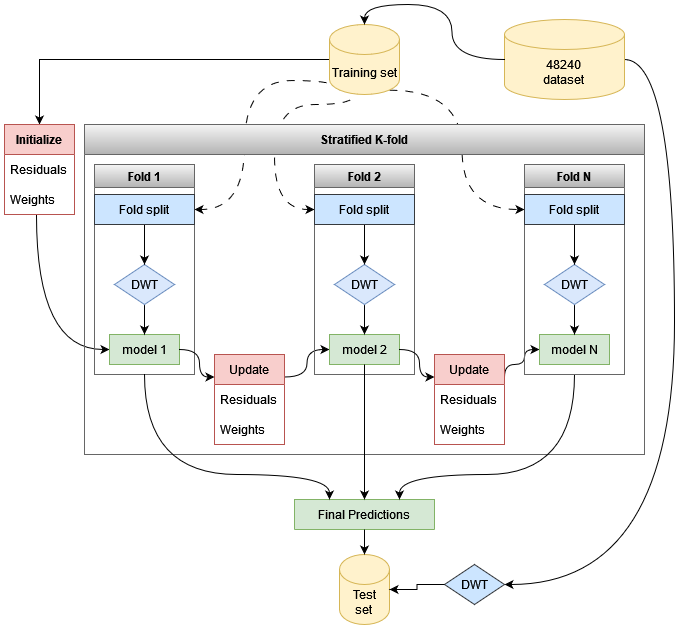

## 2.1. Smart-DWT-Ensemble on 48240 dataset featuring cnn + adaboost + gradboost + DWT (on the fly) + kfold

In [ ]:
# tf.keras.backend.clear_session()
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
#from keras.optimizers import Adam
from tensorflow.keras.optimizers.legacy import Adam
from keras import backend as K 
from tensorflow.keras.utils import Sequence
import keras
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import os
import random as rn
import time
import pywt
import cv2
from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import gc

start_time = time.time()

# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
#setup_seed(42)
#------------
# Wavelet Transformation Function with region selection
def wavelet_transform(image, region='LL', wavelet='db2', level=3, target_size=(32, 32)):
    wavelet_mode = 'periodization'

    # Applying 3-level DWT to each color channel separately
    C_R = pywt.wavedec2(image[:, :, 0], wavelet, mode=wavelet_mode, level=level)
    C_G = pywt.wavedec2(image[:, :, 1], wavelet, mode=wavelet_mode, level=level)
    C_B = pywt.wavedec2(image[:, :, 2], wavelet, mode=wavelet_mode, level=level)

    # Function to scale coefficients to [0, 255] range
    def scale_coefficients(coeff):
        coeff_min = np.min(coeff)
        coeff_max = np.max(coeff)
        if coeff_max - coeff_min == 0:
            return coeff
        scaled_coeff = 255 * (coeff - coeff_min) / (coeff_max - coeff_min)
        
        del coeff_min,coeff_max,coeff
        gc.collect()
        
        return scaled_coeff

    # Extract and scale the coefficients for each color channel
    CA3_R = scale_coefficients(C_R[0])
    (CH3_R, CV3_R, CD3_R) = [scale_coefficients(c) for c in C_R[-level]]
    CA3_G = scale_coefficients(C_G[0])
    (CH3_G, CV3_G, CD3_G) = [scale_coefficients(c) for c in C_G[-level]]
    CA3_B = scale_coefficients(C_B[0])
    (CH3_B, CV3_B, CD3_B) = [scale_coefficients(c) for c in C_B[-level]]

    # Create a single RGB image for each coefficient plot
    def create_rgb_image(channel_r, channel_g, channel_b):
        h, w = channel_r.shape
        rgb_image = np.zeros((h, w, 3), dtype=np.uint8)
        rgb_image[:, :, 0] = channel_r
        rgb_image[:, :, 1] = channel_g
        rgb_image[:, :, 2] = channel_b
        del h,w,channel_r,channel_g,channel_b
        
        return rgb_image

    # Choose the appropriate region
    if region == 'LL':
        transformed_image = create_rgb_image(CA3_R, CA3_G, CA3_B)
    elif region == 'LH':
        transformed_image = create_rgb_image(CH3_R, CH3_G, CH3_B)
    elif region == 'HL':
        transformed_image = create_rgb_image(CV3_R, CV3_G, CV3_B)
    elif region == 'HH':
        transformed_image = create_rgb_image(CD3_R, CD3_G, CD3_B)
    else:
        raise ValueError("Invalid region specified. Choose from 'LL', 'LH', 'HL', 'HH'.")

    del CH3_R, CV3_R, CD3_R
    del CH3_G, CV3_G, CD3_G
    del CH3_B, CV3_B, CD3_B
    del C_R, C_G, C_B
    gc.collect()

    # Resize the transformed image to the target size
    #transformed_image = cv2.resize(transformed_image, target_size)

    return transformed_image


# Set up ImageDataGenerator with dynamic region parameter
#def create_datagen_with_wavelet(region):
#    return ImageDataGenerator(preprocessing_function=lambda x: custom_preprocess_function(x, region=region))    
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input

def create_datagen_with_wavelet(region, wavelet='db2', level=3, target_size=(32, 32), preprocessing_function=True):
    def wavelet_transform_function(img):
        return wavelet_transform(img, region=region, wavelet=wavelet, level=level, target_size=target_size)

    if preprocessing_function:
        datagen = ImageDataGenerator(
            preprocessing_function=densenet_preprocess_input
        )
    else:
        datagen = ImageDataGenerator(
            preprocessing_function=wavelet_transform_function
        )

    return datagen

def create_cnn_model(input_shape):
    #"""
    model = Sequential()
    model.add(Conv2D(8, (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    
    #"""
    """
    from tensorflow.keras.applications import DenseNet121
    base_model = DenseNet121(include_top=False, input_shape=(img_width,img_height, 3))
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
     # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    """
    #model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])
    
    return model
    
def compute_sample_weights(y_true, y_pred, epsilon=2):
    # Convert predictions to binary class labels
    y_pred_binary = (y_pred >= 0.5).astype(int)
    #print(y_pred_binary)
    
    # Identify misclassified samples
    misclassified = (y_true != y_pred_binary)
    #print("y_true: ",y_true)
    #print("y_pred_binary: ",y_pred_binary)
    
    #print("misclassified: ",len(misclassified))
    # Count the number of misclassified samples
    num_misclassified = np.sum(misclassified)

    # Print the number of misclassified samples
    print(f"Number of misclassified samples: {num_misclassified}")
    
    # Compute residuals
    residuals = np.abs(y_true - y_pred_binary)
    
    # Assign higher weights to misclassified samples
    misclassified_weights = residuals + epsilon
    correct_classified_weights = 1
    weights = np.where(misclassified,  misclassified_weights, correct_classified_weights)
    
    del y_pred_binary,misclassified,num_misclassified
    gc.collect()
    
    print("epsilon + residuals: ",residuals + epsilon)
    
    return weights

class ResidualDataGenerator(Sequence):
    def __init__(self, data_generator, sample_weights):
        self.data_generator = data_generator
        self.sample_weights = sample_weights

    def __len__(self):
        return len(self.data_generator)

    def __getitem__(self, index):
        x_batch, y_batch = self.data_generator[index]
        gc.collect()
        return x_batch, y_batch, self.sample_weights[index * self.data_generator.batch_size:(index + 1) * self.data_generator.batch_size]

def train_gradient_boosting(num_folds, input_shape, learning_rate, mode, level, img_width, img_height, batch_size, epochs, all_images, all_labels, testing_path1):
    models = []
    histories = []
    from sklearn.model_selection import StratifiedKFold
    
    # Initialize weights to 1 for all samples
    sample_weights = np.ones(len(all_labels))
    
    kfold = StratifiedKFold(n_splits=num_folds, shuffle=False)
    regions = ['LL', 'LH', 'HL', 'HH']

    for fold_index, (train_idx, val_idx) in enumerate(kfold.split(all_images, all_labels)):
        i = fold_index % len(regions)
        print(f"--> Starting Fold {fold_index+1}/{num_folds} with region: {regions[i]}")

        x_train_fold = all_images[train_idx]
        y_train_fold = all_labels[train_idx]
        x_val_fold = all_images[val_idx]
        y_val_fold = all_labels[val_idx]

        print("- Training samples: ", len(y_train_fold))
        print("- Validation samples: ", len(y_val_fold))

        train_generator = create_datagen_with_wavelet(regions[i], mode, level).flow(x_train_fold, y_train_fold, batch_size=batch_size, shuffle=True)
        valid_generator = create_datagen_with_wavelet(regions[i], mode, level).flow(x_val_fold, y_val_fold, batch_size=batch_size, shuffle=False)

        residuals_generator = ResidualDataGenerator(train_generator, sample_weights[train_idx])

        model = create_cnn_model(input_shape)
        model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])

        checkpoint = ModelCheckpoint(f"best_model_fold_{fold_index+1}.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
        lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)

        # Train the model with sample weights
        history = model.fit(
            residuals_generator,
            validation_data=valid_generator,
            epochs=epochs,
            callbacks=[checkpoint, early_stopping],
            verbose=1
        )

        # Predict on training and validation data
        y_pred_train = model.predict(train_generator).flatten()
        y_pred_val = model.predict(valid_generator).flatten()

        # Compute weights based on misclassified samples
        weights_train = compute_sample_weights(y_train_fold, y_pred_train, 1.5)
        weights_val = compute_sample_weights(y_val_fold, y_pred_val, 1.5)

        # Apply higher weights to misclassified samples
        sample_weights[train_idx] = weights_train
        sample_weights[val_idx] = weights_val

        models.append(model)
        histories.append(history)

        # Clear session and free up memory
        tf.keras.backend.clear_session()
        del x_train_fold, y_train_fold, x_val_fold, y_val_fold, train_generator, valid_generator, residuals_generator, model
        gc.collect()

    
    return models, histories

def gradient_boosting_predict(models, test_generator):
    num_samples = test_generator.samples
    batch_size = test_generator.batch_size
    predictions_matrix = np.zeros((num_samples, len(models)))

    # Iterate through models
    for idx, model in enumerate(models):
        # Predict for all batches in one go
        predictions_matrix[:, idx] = model.predict(test_generator, verbose=1).flatten()

    # Vectorized final predictions
    true_labels = test_generator.classes
    positive_case = true_labels == 1
    negative_case = ~positive_case

    final_predictions = np.zeros(num_samples)
    for i in range(num_samples):
        if true_labels[i] == 1:
            # Check if any model predicts positive
            if np.any(predictions_matrix[i] >= 0.5):
                final_predictions[i] = 1
            else:
                final_predictions[i] = 0
        else:
            # Check if any model predicts negative
            if np.any(predictions_matrix[i] < 0.5):
                final_predictions[i] = 0
            else:
                final_predictions[i] = 1
    

    return final_predictions.astype(int)


def load_images_and_labels(directory_path, target_size):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory_path))  # List all subdirectories (class names)
    
    for class_name in class_names:
        class_path = os.path.join(directory_path, class_name)
        if not os.path.isdir(class_path):
            continue
        image_files = [os.path.join(class_path, fname) for fname in os.listdir(class_path) if fname.endswith(('.png', '.jpg', '.jpeg'))]
        
        for image_file in image_files:
            img = load_img(image_file, target_size=target_size)
            img_array = img_to_array(img)
            
            images.append(img_array)
            labels.append(class_name)  # Append the class label
            
            del img_array,img,image_file
            #gc.collect()
        del class_path,class_name,image_files
            
    del class_names
            
    images = np.array(images)
    labels = np.array(labels)
    
    # Ensure that images and labels have the same length
    if len(images) != len(labels):
        raise ValueError(f"Number of images ({len(images)}) does not match number of labels ({len(labels)}).")
        
    #encode labels
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(labels)
    
    gc.collect()
    
    return images, labels


# Load data
seed =46
setup_seed(seed)
img_width, img_height = 32, 32
level = 3
mode = 'db2'
batch_size = 64
input_shape = (img_width, img_height, 3)
num_learners = 12
epochs = 1
#learning_rate = 0.00000001  # A smaller learning rate for updating predictions
learning_rate = 0.1
train_dataset1 = '/kaggle/input/data-48240-train-test-only/Data_48240_train_test_only/Training'
testing_path1  = '/kaggle/input/data-48240-train-test-only/Data_48240_train_test_only/Test'
#train_dataset1 = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_913\\Data_913\\latest\\data913_80_20_train_test_only\\Training'
#testing_path1  = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_913\\Data_913\\latest\\data913_80_20_train_test_only\\Test'

all_images, all_labels = load_images_and_labels(train_dataset1, target_size=(img_width, img_height))

# Train Gradient Boosting
models, histories = train_gradient_boosting(
    num_folds=num_learners,  # Number of folds, corresponds to the number of regions (LL, LH, HL, HH)
    input_shape=(img_width, img_height, 3),
    learning_rate=learning_rate,
    mode=mode,
    level=level,
    img_width=img_width,
    img_height=img_height,
    batch_size=batch_size,
    epochs=epochs,
    all_images= all_images,
    all_labels = all_labels,
    testing_path1=testing_path1  # Path to the testing dataset
)

# Predict on test set
test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
        testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)

y_pred = gradient_boosting_predict(models, test_generator)

# Evaluate results
target_names = ['Malware', 'Software']
print('Confusion Matrix')
print(confusion_matrix(test_generator.classes, y_pred))
print('Classification Report')
print(classification_report(test_generator.classes, y_pred, target_names=target_names, zero_division=1, digits=5))

# calculate elapesed runtime
end_time = time.time()
runtime_seconds = end_time - start_time
runtime_minutes = runtime_seconds / 60
runtime_hours = runtime_minutes / 60
print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")
# 10 epochs with lr = 0.01
# 0.1 with 1 epoch X
# 0.1 with 3 epoch

In [ ]:
print(np.__version__)
print(keras.__version__)

In [ ]:
tf.keras.backend.clear_session()

## 2.2. Smart-DWT-Ensemble on 913 dataset featuring cnn + adaboost + gradboost + DWT (on the fly) + kfold

In [ ]:
# tf.keras.backend.clear_session()
import tensorflow as tf
print(tf.__version__)
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
#from keras.optimizers import Adam
from tensorflow.keras.optimizers.legacy import Adam

from sklearn.metrics import classification_report, confusion_matrix
import os
import random as rn
import time
import pywt
import cv2
from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.image import load_img, img_to_array


start_time = time.time()

# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
#setup_seed(42)
#------------
# Wavelet Transformation Function with region selection
def wavelet_transform(image, region='LL', wavelet='db2', level=3, target_size=(32, 32)):
    wavelet_mode = 'periodization'

    # Applying 3-level DWT to each color channel separately
    C_R = pywt.wavedec2(image[:, :, 0], wavelet, mode=wavelet_mode, level=level)
    C_G = pywt.wavedec2(image[:, :, 1], wavelet, mode=wavelet_mode, level=level)
    C_B = pywt.wavedec2(image[:, :, 2], wavelet, mode=wavelet_mode, level=level)

    # Function to scale coefficients to [0, 255] range
    def scale_coefficients(coeff):
        coeff_min = np.min(coeff)
        coeff_max = np.max(coeff)
        if coeff_max - coeff_min == 0:
            return coeff
        scaled_coeff = 255 * (coeff - coeff_min) / (coeff_max - coeff_min)
        return scaled_coeff

    # Extract and scale the coefficients for each color channel
    CA3_R = scale_coefficients(C_R[0])
    (CH3_R, CV3_R, CD3_R) = [scale_coefficients(c) for c in C_R[-level]]
    CA3_G = scale_coefficients(C_G[0])
    (CH3_G, CV3_G, CD3_G) = [scale_coefficients(c) for c in C_G[-level]]
    CA3_B = scale_coefficients(C_B[0])
    (CH3_B, CV3_B, CD3_B) = [scale_coefficients(c) for c in C_B[-level]]

    # Create a single RGB image for each coefficient plot
    def create_rgb_image(channel_r, channel_g, channel_b):
        h, w = channel_r.shape
        rgb_image = np.zeros((h, w, 3), dtype=np.uint8)
        rgb_image[:, :, 0] = channel_r
        rgb_image[:, :, 1] = channel_g
        rgb_image[:, :, 2] = channel_b
        return rgb_image

    # Choose the appropriate region
    if region == 'LL':
        transformed_image = create_rgb_image(CA3_R, CA3_G, CA3_B)
    elif region == 'LH':
        transformed_image = create_rgb_image(CH3_R, CH3_G, CH3_B)
    elif region == 'HL':
        transformed_image = create_rgb_image(CV3_R, CV3_G, CV3_B)
    elif region == 'HH':
        transformed_image = create_rgb_image(CD3_R, CD3_G, CD3_B)
    else:
        raise ValueError("Invalid region specified. Choose from 'LL', 'LH', 'HL', 'HH'.")

    # Resize the transformed image to the target size
    #transformed_image = cv2.resize(transformed_image, target_size)

    return transformed_image


# Set up ImageDataGenerator with dynamic region parameter
#def create_datagen_with_wavelet(region):
#    return ImageDataGenerator(preprocessing_function=lambda x: custom_preprocess_function(x, region=region))    
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input

def create_datagen_with_wavelet(region, wavelet='db2', level=3, target_size=(32, 32), preprocessing_function=True):
    def wavelet_transform_function(img):
        return wavelet_transform(img, region=region, wavelet=wavelet, level=level, target_size=target_size)

    if preprocessing_function:
        datagen = ImageDataGenerator(
            preprocessing_function=densenet_preprocess_input
        )
    else:
        datagen = ImageDataGenerator(
            preprocessing_function=wavelet_transform_function
        )

    return datagen

def create_cnn_model(input_shape):
    #"""
    model = Sequential()
    model.add(Conv2D(8, (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    
    #"""
    """
    from tensorflow.keras.applications import DenseNet121
    base_model = DenseNet121(include_top=False, input_shape=(img_width,img_height, 3))
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
     # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    """
    #model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])
    
    return model
    
def compute_residuals(y_true, y_pred):
    return y_true - y_pred

def compute_sample_weights(y_true, y_pred, epsilon=2):
    # Convert predictions to binary class labels
    y_pred_binary = (y_pred >= 0.5).astype(int)
    #print(y_pred_binary)
    
    # Identify misclassified samples
    misclassified = (y_true != y_pred_binary)
    #print("y_true: ",y_true)
    #print("y_pred_binary: ",y_pred_binary)
    
    #print("misclassified: ",len(misclassified))
    # Count the number of misclassified samples
    num_misclassified = np.sum(misclassified)

    # Print the number of misclassified samples
    print(f"Number of misclassified samples: {num_misclassified}")
    
    # Compute residuals
    residuals = np.abs(y_true - y_pred_binary)
    
    # Assign higher weights to misclassified samples
    misclassified_weights = residuals + epsilon
    correct_classified_weights = 1
    weights = np.where(misclassified,  misclassified_weights, correct_classified_weights)
    
    #print("epsilon + residuals: ",residuals + epsilon)
    
    return weights

class ResidualDataGenerator(Sequence):
    def __init__(self, data_generator, sample_weights):
        self.data_generator = data_generator
        self.sample_weights = sample_weights

    def __len__(self):
        return len(self.data_generator)

    def __getitem__(self, index):
        x_batch, y_batch = self.data_generator[index]
        return x_batch, y_batch, self.sample_weights[index * self.data_generator.batch_size:(index + 1) * self.data_generator.batch_size]

def train_gradient_boosting(num_folds, input_shape, learning_rate, mode, level, img_width, img_height, batch_size, epochs, all_images, all_labels, testing_path1):
    models = []
    histories = []
    from sklearn.model_selection import StratifiedKFold
    
    # Initialize weights to 1 for all samples
    sample_weights = np.ones(len(all_labels))
    
    kfold = StratifiedKFold(n_splits=num_folds, shuffle=False)
    regions = ['LL', 'LH', 'HL', 'HH']

    for fold_index, (train_idx, val_idx) in enumerate(kfold.split(all_images, all_labels)):
        i = fold_index % len(regions)
        print(f"--> Starting Fold {fold_index+1}/{num_folds} with region: {regions[i]}")

        x_train_fold = all_images[train_idx]
        y_train_fold = all_labels[train_idx]
        x_val_fold = all_images[val_idx]
        y_val_fold = all_labels[val_idx]

        print("- Training samples: ", len(y_train_fold))
        print("- Validation samples: ", len(y_val_fold))

        train_generator = create_datagen_with_wavelet(regions[i], mode, level).flow(x_train_fold, y_train_fold, batch_size=batch_size, shuffle=True)
        valid_generator = create_datagen_with_wavelet(regions[i], mode, level).flow(x_val_fold, y_val_fold, batch_size=batch_size, shuffle=False)

        residuals_generator = ResidualDataGenerator(train_generator, sample_weights[train_idx])

        model = create_cnn_model(input_shape)
        model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])

        checkpoint = ModelCheckpoint(f"best_model_fold_{fold_index+1}.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
        lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)

        # Train the model with sample weights
        history = model.fit(
            residuals_generator,
            validation_data=valid_generator,
            epochs=epochs,
            callbacks=[checkpoint, early_stopping,lr_schedule],
            verbose=1
        )

        # Predict on training and validation data
        y_pred_train = model.predict(train_generator).flatten()
        y_pred_val = model.predict(valid_generator).flatten()

        # Compute weights based on misclassified samples
        weights_train = compute_sample_weights(y_train_fold, y_pred_train,1.5)
        weights_val = compute_sample_weights(y_val_fold, y_pred_val,1.5)

        # Apply higher weights to misclassified samples
        sample_weights[train_idx] = weights_train
        sample_weights[val_idx] = weights_val
        
        # Predict on validation data
        val_pred_test_model = model.predict(valid_generator)
        val_pred_test_model = np.where(val_pred_test_model > 0.5, 1, 0)

        val_true = y_val_fold

        # Evaluate results
        target_names = ['Malware', 'Software']
        print('Confusion Matrix')
        print(confusion_matrix(val_true, val_pred_test_model))
        print('Classification Report')
        print(classification_report(val_true, val_pred_test_model, target_names=target_names, zero_division=1, digits=5))

        test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
            testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)
        y_pred_test_model = model.predict(test_generator, test_generator.n // batch_size + 1)
        Y_pred_test = y_pred_test_model
        y_pred_test_model = np.where(y_pred_test_model > 0.5, 1, 0)
        #cm = confusion_matrix(test_generator.classes, test_labels)
        #print(cm)
        #print("test_labels: ",test_labels)
        test_labels = y_pred_test_model
        print(test_generator.class_indices)
        summ = 0 
        print("------------------")
        for i in range (0,len(test_generator.filenames)):
            detection_status = "Undetected      " if y_pred_test_model[i] > 0.5 else "Detected Malware"
            print(detection_status,"-",test_labels[i],"-","{:.8f}".format(Y_pred_test[i][0])," - ",test_generator.filenames[i])
            summ = summ + Y_pred_test[i][0]
        print("------------------")
        print("-> Avg malware accuracy: ",summ/13)

        models.append(model)
        histories.append(history)
    
    return models, histories


def gradient_boosting_predict(models, test_generator):
    num_samples = test_generator.samples
    batch_size = test_generator.batch_size
    predictions_matrix = np.zeros((num_samples, len(models)))

    for idx, model in enumerate(models):
        #print(idx)
        y_pred_list = []
        steps = num_samples // batch_size + (num_samples % batch_size != 0)
        
        for _ in range(steps):
            x_batch, _ = test_generator.next()
            y_pred_batch = model.predict(x_batch)
            y_pred_list.append(y_pred_batch)
        
        y_pred = np.concatenate(y_pred_list)
        
        # Ensure that predictions array is aligned
        if y_pred.shape[0] != num_samples:
            raise ValueError(f"Mismatch in prediction shape: {y_pred.shape[0]} != {num_samples}")
        
        predictions_matrix[:, idx] = y_pred.flatten()
    
    #each line, per sample for all models 
    print(predictions_matrix)
    
    #print("-> Avg malware accuracy: ",sum(y_pred)/13)
    # Check if any model's prediction is correct for each sample
    final_predictions = np.zeros(num_samples)
    true_labels = test_generator.classes
    for i in range(num_samples):
        # Compute distances from the true label (1 or 0)
        distances = np.abs(predictions_matrix[i] - true_labels[i])
        # Find the index of the minimum distance
        closest_model_index = np.argmin(distances)
        #print(closest_model_index)
        # Save the probability of the closest model
        final_predictions[i] = predictions_matrix[i][closest_model_index]
    
    print(final_predictions)

    return final_predictions

def load_images_and_labels(directory_path, target_size):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory_path))  # List all subdirectories (class names)
    
    for class_name in class_names:
        class_path = os.path.join(directory_path, class_name)
        if not os.path.isdir(class_path):
            continue
        image_files = [os.path.join(class_path, fname) for fname in os.listdir(class_path) if fname.endswith(('.png', '.jpg', '.jpeg'))]
        
        for image_file in image_files:
            img = load_img(image_file, target_size=target_size)
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(class_name)  # Append the class label
            
    images = np.array(images)
    labels = np.array(labels)
    
    # Ensure that images and labels have the same length
    if len(images) != len(labels):
        raise ValueError(f"Number of images ({len(images)}) does not match number of labels ({len(labels)}).")
        
    #encode labels
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(labels)
    
    return images, labels

#import sys
#old_stdout = sys.stdout # keep reference to existing stdout
#sys.stdout = open('logfile.txt', 'w')

accuracies = []
for i in range(1):
    # Load data
    seed = i
    setup_seed(seed)
    img_width, img_height = 64, 64
    level = 2
    mode = 'db2'
    batch_size = 64
    input_shape = (img_width, img_height, 3)
    num_learners = 8
    epochs = 1
    learning_rate = 0.1  # A smaller learning rate for updating predictions
    #train_dataset1 = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_48240\\latest\\Data_48240_train_test_only\\Training'
    #testing_path1  = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_48240\\latest\\Data_48240_train_test_only\\Test'
    train_dataset1 = '/kaggle/input/data913-80-20-train-test-only/data913_80_20_train_test_only/Training'
    testing_path1  = '/kaggle/input/data913-80-20-train-test-only/data913_80_20_train_test_only/Test'

    all_images, all_labels = load_images_and_labels(train_dataset1, target_size=(img_width, img_height))

    # Train Gradient Boosting
    models, histories = train_gradient_boosting(
        num_folds=num_learners,  # Number of folds, corresponds to the number of regions (LL, LH, HL, HH)
        input_shape=(img_width, img_height, 3),
        learning_rate=learning_rate,
        mode=mode,
        level=level,
        img_width=img_width,
        img_height=img_height,
        batch_size=batch_size,
        epochs=epochs,
        all_images= all_images,
        all_labels = all_labels,
        testing_path1=testing_path1  # Path to the testing dataset
    )

    # Predict on test set
    test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
            testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)

    y_pred = gradient_boosting_predict(models, test_generator)

    # DATA_913
    print(test_generator.class_indices)
    print("------------------")
    for i in range(len(test_generator.filenames)):
        detection_status = "Undetected      " if y_pred[i] > 0.5 else "Detected Malware"
        print(f"{detection_status} - {y_pred[i]:.8f} - {test_generator.filenames[i]}")
    print("------------------")
    print("-> Avg malware accuracy: ",sum(y_pred)/13)
    #"""
    
    accuracies.append(sum(y_pred)/13)

    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

    import numpy as np

    # Assuming y_true and y_pred are already obtained
    y_true = test_generator.classes  # Ground truth labels

    class_of_interest = 0  # Assuming Software is class 0, Malware is class 1

    print("y_true: ",y_true)
    y_pred_binary = y_pred
    for i in range(len(test_generator.filenames)):
        y_pred_binary[i] = 1 if y_pred_binary[i] >= 0.5 else 0
    #y_pred_binary = [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] #for testing purposes
    print("y_pred_binary: ",y_pred_binary)
    # Create the classification report only for classes present in y_true
    unique_classes = np.unique(y_true)
    labels = unique_classes  # Use only classes present in y_true
    target_names = ['Malware' if cls == 0 else 'Software' for cls in labels]

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_pred_binary, labels=labels)
    print(f"Confusion Matrix:\n{conf_matrix}")
    class_report = classification_report(y_true, y_pred_binary, labels=labels, target_names=target_names, zero_division=1, digits=5)
    print(class_report)
    # Compute and print accuracy
    #accuracy = accuracy_score(y_true, y_pred_binary)
    #print(f"Accuracy: {accuracy:.5f}")

    print("seed: ",seed)

    # calculate elapesed runtime
    end_time = time.time()
    runtime_seconds = end_time - start_time
    runtime_minutes = runtime_seconds / 60
    runtime_hours = runtime_minutes / 60
    print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")
    # 10 epochs with lr = 0.01
    
    #from IPython.core.display import HTML
    #HTML("<script>Jupyter.notebook.kernel.restart()</script>")
    
    print("###################################")
    
average = sum(accuracies) / len(accuracies)

# Print the average with 6 decimal places
print(f"{average:.6f}")
#sys.stdout = old_stdout # restore stdout